In [1]:
import os
import inspect
n_cores = 4
os.environ["XLA_FLAGS"] = '--xla_force_host_platform_device_count={}'.format(n_cores)

from jax import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import numpy as np
import pickle
from jax import jit, vmap, grad, jacrev, lax
from jax.lax import cond, scan
import jax.random as random
key = random.PRNGKey(2022)
import jax.example_libraries.optimizers as optimizers
from jax.flatten_util import ravel_pytree
from jax.sharding import PositionalSharding
from functools import partial

import matplotlib.pyplot as plt
import pandas as pd

from utils import train, coords_2_strain_nn
from utils import train_colloc_parallel_weak
from utils import train_colloc_parallel as train_colloc,init_params_nn, ff_nn, divergence, bd_forces, a1, a2, lr
from utils_hyperelasticity import NODE, init_layers, NODE_model_aniso, init_params_aniso, GOH_model, eval_Cauchy, eval_Cauchy_vmap, eval_P, eval_P_vmap
from utils_hyperelasticity import ThreeDElasticity
from fem import plotmesh, plotmesh_updated,fe_solver_2D, vahid_anisohyper_inv, apply_bc_biax

from jax_fem.core import FEM
from jax_fem.solver import solver
from jax_fem.utils import save_sol
from jax_fem.generate_mesh import box_mesh, get_meshio_cell_type, Mesh, rectangle_mesh

from PIL import Image, ImageFilter
from jaxinterp2d import interp2d

E_fun = vmap(lambda F: 0.5*(F.T@F - jnp.eye(2)))

       __       ___      ___   ___                _______  _______ .___  ___. 
      |  |     /   \     \  \ /  /               |   ____||   ____||   \/   | 
      |  |    /  ^  \     \  V  /      ______    |  |__   |  |__   |  \  /  | 
.--.  |  |   /  /_\  \     >   <      |______|   |   __|  |   __|  |  |\/|  | 
|  `--'  |  /  _____  \   /  .  \                |  |     |  |____ |  |  |  | 
 \______/  /__/     \__\ /__/ \__\               |__|     |_______||__|  |__| 
                                                                              



## 1. Generate data + pretraining

In [2]:
##########################################################################this is I am using to understand the above code##### skip it when you run the code
print(inspect.getsource(Mesh))

class Mesh():
    """
    A custom mesh manager might be better using a third-party library like
    meshio.
    """
    def __init__(self, points, cells, ele_type='TET4'):
        # TODO: Assert that cells must have correct orders
        # TODO: first cells, then points?
        self.points = points
        self.cells = cells
        self.ele_type = ele_type

    def count_selected_faces(self, location_fn):
        """Given location functions, compute the count of faces that satisfy
        the location function. Useful for setting up distributed load
        conditions.

        Parameters
        ----------
        location_fns : List[Callable]
            Callable: a function that inputs a point and returns a boolean
            value describing whether the boundary condition should be applied.

        Returns
        -------
        face_count : int
        """

        _, _, _, _, face_inds = get_face_shape_vals_and_grads(self.ele_type)
        cell_points = onp.take(self.point

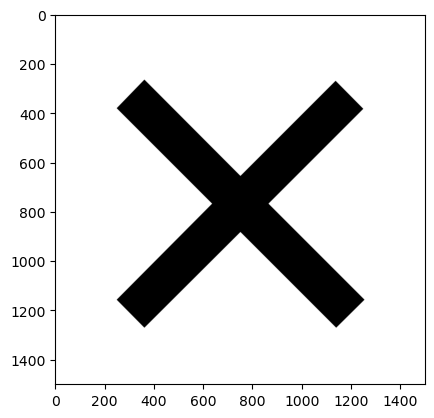

In [3]:
ele_type = 'QUAD4'
cell_type = get_meshio_cell_type(ele_type)
Nx, Ny = 100, 100
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
image = Image.open('×.png')
# image = image.filter(ImageFilter.GaussianBlur(radius=60))
plt.imshow(image)
image = image.rotate(-90)
image = np.array(image)
image = image.mean(axis=2)
image = image/image.max()

pts_x = np.linspace(0,1,image.shape[0])
pts_y = np.linspace(0,1,image.shape[1])

def coords_2_params_gt(xy):
    x, y = xy
    c = interp2d(x,y,pts_x,pts_y,image)
    ##### image size is 1500 by 1500 but the range of values are x,y, pts_x and pts_y are between [0,1]
    return jnp.stack([0.5,0.10,0.20,0.1,0.0]) + c*jnp.stack([0.2,0.02,0.04,0.0,0.0])

In [4]:
GOH_P_vmap = vmap(ThreeDElasticity(GOH_model).ugrad_2_P, in_axes=(0, 0, None))
class HyperElasticity(FEM):
    def get_tensor_map(self):
        return lambda u_grad, params: ThreeDElasticity(GOH_model).ugrad_2_P(u_grad, params, self.dim)
    
    def set_params(self, params_vec):
        self.internal_vars['laplace'] = [params_vec]

In [5]:
##########################################################################this is I am using to understand the above code##### skip it when you run the code
print(GOH_model)
print(inspect.getsource(ThreeDElasticity))

<class 'utils_hyperelasticity.GOH_model'>
class ThreeDElasticity():
    def __init__(self, model):
        self.model = model

    def ugrad_2_P(self, u_grad, params, dim):
        theta = 0.0
        #Kinematics
        F_2D = u_grad + jnp.eye(dim)
        C_2D = F_2D.T @ F_2D
        Cinv_2D = jnp.linalg.inv(C_2D)
        detC_2D = jnp.linalg.det(C_2D)
        C33 = 1/detC_2D
        C = jnp.array([  [C_2D[0,0], C_2D[0,1], 0],\
                        [C_2D[1,0], C_2D[1,1], 0],\
                        [0,         0,       C33]])
        C2 = C @ C
        Cinv = jnp.linalg.inv(C)
        I1 = C[0,0] + C[1,1] + C[2,2]
        trC2 = C2[0,0] + C2[1,1] + C2[2,2]
        I2 = 0.5*(I1**2 - trC2)
        v0 = jnp.array([ jnp.cos(theta), jnp.sin(theta), 0])
        w0 = jnp.array([-jnp.sin(theta), jnp.cos(theta), 0])
        V0 = jnp.outer(v0, v0)
        W0 = jnp.outer(w0, w0)
        Iv = jnp.einsum('ij,ij',C,V0)
        Iw = jnp.einsum('ij,ij',C,W0)

        # Energy/Stress
        mode

In [6]:
ele_type = 'QUAD4'
cell_type = get_meshio_cell_type(ele_type)

Nx, Ny = 50, 50
Lx, Ly = 1.0, 1.0
meshio_mesh = rectangle_mesh(Nx=Nx, Ny=Ny, domain_x=Lx, domain_y=Ly)
mesh = Mesh(meshio_mesh.points, meshio_mesh.cells_dict[cell_type])
print(mesh)

# Functions to identify the boundary nodes
def bottom(point):
    return jnp.isclose(point[1], 0., atol=1e-5)
def left(point):
    return jnp.isclose(point[0], 0., atol=1e-5)
def top(point):
    return jnp.isclose(point[1], Ly, atol=1e-5)
def right(point):
    return jnp.isclose(point[0], Lx, atol=1e-5)
def bottom_left(point):
    return jnp.logical_and(jnp.logical_and(bottom(point), left(point)), jnp.isclose(point[2], 0., atol=1e-5))


# Functions to assign dirichlet BCs
def zero_dirichlet(point):
    return 0.
def lmbx_max_dirichlet(point, lmbx_max):
    return Lx*lmbx_max - 1.0
def lmby_max_dirichlet(point, lmby_max):
    return Ly*lmby_max - 1.0


lmb_hist = [1.05, 1.10, 1.15, 1.20]
n_elem = Nx*Ny
F_hist_goh = []
P_hist_goh = []
for lmb_max in lmb_hist:
    dirichlet_bc_info = [
        [bottom,            left,           top,                                        right,                                  ],
        [1,                 0,              1,                                          0,                                      ],
        [zero_dirichlet,    zero_dirichlet, lambda p: lmby_max_dirichlet(p, lmb_max),   lambda p: lmbx_max_dirichlet(p, lmb_max)]
    ]
    problem = HyperElasticity(mesh,
                            vec=2,
                            dim=2,
                            ele_type=ele_type,
                            dirichlet_bc_info=dirichlet_bc_info)
    elem_X = problem.get_physical_quad_points().mean(1)

    # params = vmap(coords_2_params_gt)(elem_X)
    params = []
    for xy in elem_X:
        params.append(coords_2_params_gt(xy))
    params = np.expand_dims(params, 1)
    params_vec = jnp.repeat(params, axis=1, repeats=4)
    problem.set_params(params_vec)


    u = solver(problem, use_petsc=True)
    u_grad = np.mean(problem.sol_to_grad(u), axis=1)
    F = u_grad + np.eye(2)

    P = GOH_P_vmap(u_grad, params_vec[:,0,:], 2)
    
    F_hist_goh.append(F)
    P_hist_goh.append(P)
F_hist_goh = np.array(F_hist_goh)
P_hist_goh = np.array(P_hist_goh)

[10-24 13:25:31][DEBUG] jax_fem: Computing shape function values, gradients, etc.


[10-24 13:25:31][DEBUG] jax_fem: ele_type = QUAD4, quad_points.shape = (num_quads, dim) = (4, 2)
[10-24 13:25:31][DEBUG] jax_fem: face_quad_points.shape = (num_faces, num_face_quads, dim) = (4, 2, 2)


[10-24 13:25:32][DEBUG] jax_fem: Done pre-computations, took 1.0888035297393799 [s]
[10-24 13:25:32][INFO] jax_fem: Solving a problem with 2500 cells, 2601x2 = 5202 dofs.
[10-24 13:25:35][DEBUG] jax_fem: Calling the row elimination solver for imposing Dirichlet B.C.
[10-24 13:25:35][DEBUG] jax_fem: Start timing
[10-24 13:25:35][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[10-24 13:25:37][DEBUG] jax_fem: Function split_and_compute_cell took 1.7229 seconds
[10-24 13:25:37][DEBUG] jax_fem: Creating sparse matrix with scipy...
[10-24 13:25:38][DEBUG] jax_fem: Linear guess solve...
[10-24 13:25:38][DEBUG] jax_fem: PETSc - Solving with ksp_type = bcgsl, pc = ilu
[10-24 13:25:38][DEBUG] jax_fem: PETSc linear solve res = 2.922363883893081e-06
[10-24 13:25:38][DEBUG] jax_fem: Computing cell Jacobian and cell residual...
[10-24 13:25:38][DEBUG] jax_fem: Function split_and_compute_cell took 0.0367 seconds
[10-24 13:25:38][DEBUG] jax_fem: Creating sparse matrix with scipy...
[10-2

(2500, 2)
(2500, 2)
(2500, 2)
(2500, 2)


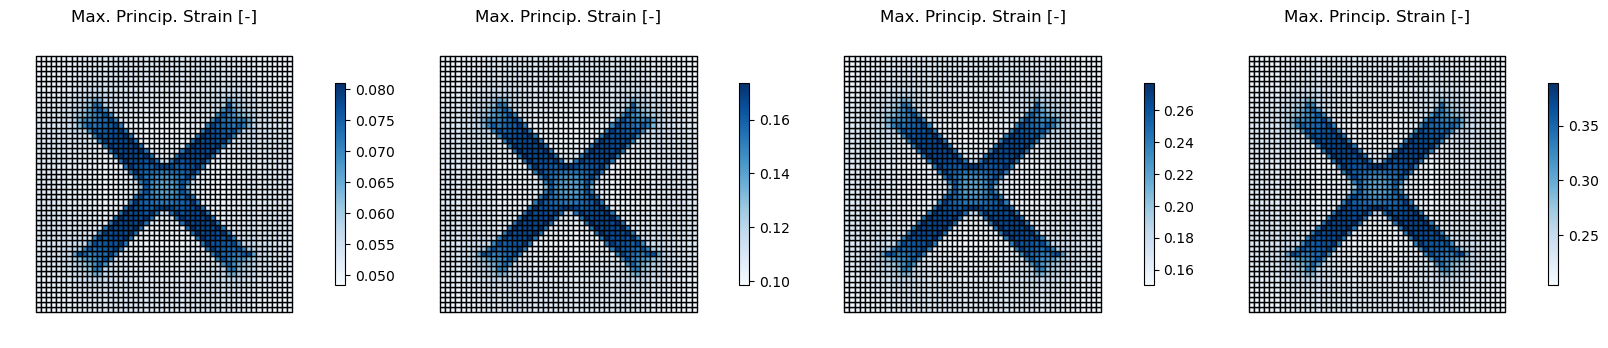

In [7]:
fig, axes = plt.subplots(1,4,figsize=(20,4))
strains = []
t_hist = np.arange(len(lmb_hist))
for t, F, P, ax in zip(t_hist, F_hist_goh, P_hist_goh, axes):
    E = E_fun(F)
    evals, efuns = jnp.linalg.eigh(E)
    print(evals.shape)
    E_11, E_22 = evals.T

    mps = np.maximum(E_11, E_22)
    plotmesh(mesh.cells, mesh.points, mps, title='Max. Princip. Strain [-]', ax=ax); 

    strains.append(np.array([t*np.ones(len(F)), F[:,0,0], F[:,0,1], F[:,1,0], F[:,1,1]]))
strains = np.hstack(strains)

### Coords_2_strain NN

In [ ]:
# instead of using a 2D spline, use a NN to get the strain field for a given (x,y)
def loss_coords_2_strain(params, X, key):
    inp, out_gt = X[:,:3], X[:,3:] #inp: x,y,lmb and out_gt=eps_xx, eps_yy
    t = inp[:,2:3]
    out_pr = coords_2_strain_nn(inp, params)
    out_gt = out_gt/(t+1) #dividing by t+1 just for some regularization
    out_pr = out_pr/(t+1) #dividing by t+1 just for some regularization
    return jnp.mean((out_pr-out_gt)**2)

n_ff = 40 # 10 cosines and 10 sines in the fourier features
n_inp = 2 # x, y
ff_params = np.random.normal(size=n_inp*n_ff).reshape([n_inp,n_ff])*0.5
nn_layers = [2*n_ff+1,40,40,4]
nn_params = init_params_nn(nn_layers, key)
coord_2_strain_params = [ff_params, nn_params]

opt_init, opt_update, get_params = optimizers.adam(5.e-4)
opt_state = opt_init(coord_2_strain_params)

X = np.vstack([elem_X, elem_X, elem_X, elem_X])
inp = np.hstack([X, strains.T])
coord_2_strain_params, train_loss, _ = train(loss_coords_2_strain, inp, get_params, opt_update, opt_state, key, nIter = 100000, print_freq=1000, batch_size=1000)

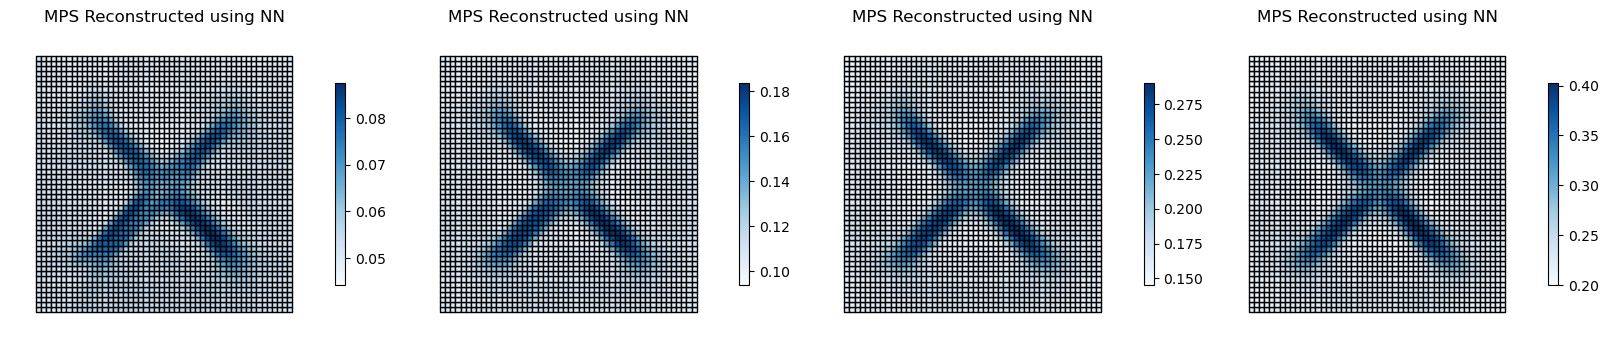

In [9]:
fig, axes = plt.subplots(1,4,figsize=(20,4))
for t in t_hist:
    ax = axes[t]
    aux = np.hstack([elem_X, t*np.ones_like(elem_X[:,:1])])
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn(aux, coord_2_strain_params).T
    F = np.stack([F_xx, F_xy, F_yx, F_yy]).T.reshape([-1,2,2])
    
    E = E_fun(F)
    evals, efuns = jnp.linalg.eigh(E)
    E_11, E_22 = evals.T
    mps = np.maximum(E_11, E_22)

    plotmesh(mesh.cells, mesh.points, mps, title='MPS Reconstructed using NN', ax=ax); 

In [10]:
hx = hy = 0.02
rgt_bd_elems = []
top_bd_elems = []
lft_bd_elems = []
bot_bd_elems = []
for i, e in enumerate(mesh.cells):
    if any([mesh.points[e[i],0]>0.99 for i in range(4)]):
        rgt_bd_elems.append(i)
    if any([mesh.points[e[i],1]>0.99 for i in range(4)]):
        top_bd_elems.append(i)
    if any([mesh.points[e[i],0]<0.01 for i in range(4)]):
        lft_bd_elems.append(i)
    if any([mesh.points[e[i],1]<0.01 for i in range(4)]):
        bot_bd_elems.append(i)

# get the reaction forces by integrating the stresses of the boundary elements
rgt_bd_frc = np.sum(P_hist_goh[:,rgt_bd_elems,0,0], axis=1)*hy
lft_bd_frc = np.sum(P_hist_goh[:,lft_bd_elems,0,0], axis=1)*hy
top_bd_frc = np.sum(P_hist_goh[:,top_bd_elems,1,1], axis=1)*hx
bot_bd_frc = np.sum(P_hist_goh[:,bot_bd_elems,1,1], axis=1)*hx
Force_x = jnp.array(0.5*(rgt_bd_frc + lft_bd_frc))
Force_y = jnp.array(0.5*(top_bd_frc + bot_bd_frc))

# get the center points of the elements
rgt_bd_X = elem_X[rgt_bd_elems]
top_bd_X = elem_X[top_bd_elems]
lft_bd_X = elem_X[lft_bd_elems]
bot_bd_X = elem_X[bot_bd_elems]
bd_X = rgt_bd_X, top_bd_X, lft_bd_X, bot_bd_X

In [ ]:
print(rgt_bd_frc)
print(lft_bd_frc)
print(top_bd_frc )
print(bot_bd_frc)
print(elem_X.shape)
print(bd_X)

In [ ]:
# Homogenize the strains
F_xx_mean = np.mean(F_hist_goh[:,:,0,0], axis=1)
F_xy_mean = np.mean(F_hist_goh[:,:,0,1], axis=1)
F_yx_mean = np.mean(F_hist_goh[:,:,1,0], axis=1)
F_yy_mean = np.mean(F_hist_goh[:,:,1,1], axis=1)

P_xx_mean = Force_x/len(rgt_bd_elems)
P_yy_mean = Force_y/len(top_bd_elems)
inputs = np.array([F_xx_mean, F_xy_mean, F_yx_mean, F_yy_mean, P_xx_mean, P_yy_mean]).T

n_neurons = 4
# Define the loss function for when training all params
@jit
def loss_stress(params, x, key):
    model = NODE_model_aniso(params)
    F_xx, F_xy, F_yx, F_yy, P_xx_gt, P_yy_gt = x.T
    P = eval_P_vmap(F_xx, F_xy, F_yx, F_yy, model)
    P_xx_pr, P_yy_pr = P[:,0,0], P[:,1,1]
    return np.mean((P_xx_pr-P_xx_gt)**2+(P_yy_pr-P_yy_gt)**2)

# Initialize NODEs and the optimizer
key = random.PRNGKey(0)
common_layers = [1, n_neurons, n_neurons]
sample_layers = [n_neurons,1]
node_params = init_params_aniso(common_layers, sample_layers, key)
opt_init, opt_update, get_params = optimizers.adam(5.e-4) #Original: 1.e-4
opt_state = opt_init(node_params)

# Train
node_params, train_loss, _ = train(loss_stress, inputs, get_params, opt_update, opt_state, key, nIter = 20000, print_freq=1000)

In [13]:
mymodel = NODE_model_aniso(node_params)
P = eval_P_vmap(F_xx_mean, F_xy_mean, F_yx_mean, F_yy_mean, mymodel)
P_xx_pr, P_yy_pr = P[:,0,0], P[:,1,1]
print('gt P_xx & P_yy: ', P_xx_mean/hx, P_yy_mean/hy)
print('pr P_xx & P_yy: ', P_xx_pr, P_yy_pr)

gt P_xx & P_yy:  [0.36299 0.65853 0.90699 1.12277] [0.35022 0.63006 0.85962 1.05284]
pr P_xx & P_yy:  [0.36164 0.66095 0.90507 1.12334] [0.34896 0.63248 0.85758 1.05347]


In [ ]:
# Fit a function Λ that maps x,y ∈ [0,1] to the individual-specific parameters of this NODE with a maximum variance of, say, 1%
phi, unravel = ravel_pytree(node_params)
n_phi = len(phi)

# ff_params = coord_2_sΛ train_params[0]
# ff_nn2 = lambda x, nn_params: ff_nn(x, [ff_params, nn_params])
def loss_Lambda(params, inp, key):
    out_pr = ff_nn(inp, params)
    return jnp.mean((out_pr-phi)**2)

n_ff = 40
ff_params = np.random.normal(size=2*n_ff).reshape([2,n_ff])
nn_layers = [2*n_ff,40,40,n_phi]
nn_params = init_params_nn(nn_layers, key)
Lambda_params = [ff_params, nn_params]
opt_init, opt_update, get_params = optimizers.adam(5.e-4) #Original: 1.e-4
opt_state = opt_init(Lambda_params)

inp = np.array(np.meshgrid(np.linspace(0,1,20), np.linspace(0,1,20))).reshape([2,-1]).T
Lambda_params, train_loss, _ = train(loss_Lambda, inp, get_params, opt_update, opt_state, key, nIter = 5000, print_freq=1000)

it 1000, train loss = 1.439497e-04
it 2000, train loss = 4.117763e-05
it 3000, train loss = 1.738574e-05
it 4000, train loss = 8.551400e-06
it 5000, train loss = 4.523801e-06


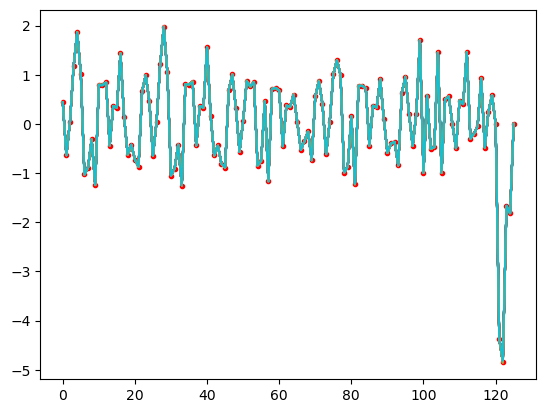

In [14]:
phi, unravel = ravel_pytree(node_params)
fig, ax = plt.subplots()
ax.plot(phi, 'r.-')
for y in np.linspace(0,1,4):
    for x in np.linspace(0,1,10):
        params = ff_nn(np.array([x,y]).reshape([1,-1]), Lambda_params)
        ax.plot(params[0])

In [ ]:
# with open('params/×_sharp_pre.npy', 'wb') as f:
#     pickle.dump([coord_2_strain_params, node_params, Lambda_params, mesh, elem_X, Force_x, Force_y, strains,
#                  bd_X, lmb_hist, P_hist_goh, F_hist_goh, t_hist], f)

In [8]:
with open('params/×_sharp_pre.npy', 'rb') as f:
    coord_2_strain_params, node_params, Lambda_params, mesh, elem_X, Force_x, Force_y, strains, \
                 bd_X, lmb_hist, P_hist_goh, F_hist_goh, t_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))
coords_2_strain_nn_ff = lambda x, params: coords_2_strain_nn(x, params)
ff_nn_ff = lambda x, params: ff_nn(x, params)

In [ ]:
def get_P(X, Y, t, Lambda_params, coord_2_strain_params, model):
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn_ff(jnp.array([X,Y,t])[None,:], coord_2_strain_params).flatten()
    # get NODE individual-specific params, phi, from the Lambda NN
    Lambda_inp = jnp.array([X,Y]).reshape([-1,2])
    phi = ff_nn_ff(Lambda_inp, Lambda_params).flatten()
    # Make predictions with this NODE
    ugrad = jnp.array([[F_xx-1.0, F_xy],[F_yx, F_yy-1.0]])
    P = ThreeDElasticity(model).ugrad_2_P(ugrad, phi, 2)
    return P[0,0], P[1,0], P[0,1], P[1,1]
get_P_vmap = vmap(get_P, in_axes=(0,0,0,None,None,None), out_axes=(0,0,0,0))

get_Pxx = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[0]
get_Pyx = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[1]
get_Pxy = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[2]
get_Pyy = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[3]

Grad_Pxx_X = vmap(grad(get_Pxx, argnums=0), in_axes=(0,0,0,None,None,None), out_axes=0) # should return dsgm_xx/dx
Grad_Pyx_X = vmap(grad(get_Pyx, argnums=0), in_axes=(0,0,0,None,None,None), out_axes=0)
Grad_Pxy_Y = vmap(grad(get_Pyx, argnums=1), in_axes=(0,0,0,None,None,None), out_axes=0)
Grad_Pyy_Y = vmap(grad(get_Pyy, argnums=1), in_axes=(0,0,0,None,None,None), out_axes=0)

@partial(jit, static_argnums=(4,))
def bd_forces(Lambda_params, t, bd_X, c2s_params, model):
    rgt_bd_X, top_bd_X, lft_bd_X, bot_bd_X = bd_X
    rgt_bd_P = get_P_vmap(rgt_bd_X[:,0], rgt_bd_X[:,1], t*jnp.ones_like(rgt_bd_X[:,0]), Lambda_params, c2s_params, model)
    top_bd_P = get_P_vmap(top_bd_X[:,0], top_bd_X[:,1], t*jnp.ones_like(top_bd_X[:,0]), Lambda_params, c2s_params, model)
    lft_bd_P = get_P_vmap(lft_bd_X[:,0], lft_bd_X[:,1], t*jnp.ones_like(lft_bd_X[:,0]), Lambda_params, c2s_params, model)
    bot_bd_P = get_P_vmap(bot_bd_X[:,0], bot_bd_X[:,1], t*jnp.ones_like(bot_bd_X[:,0]), Lambda_params, c2s_params, model)

    rgt_bd_frc = jnp.sum(rgt_bd_P[0]*1.0) # Assume area of edge = 1.0
    top_bd_frc = jnp.sum(top_bd_P[3]*1.0)
    lft_bd_frc = jnp.sum(lft_bd_P[0]*1.0)
    bot_bd_frc = jnp.sum(bot_bd_P[3]*1.0)
    return rgt_bd_frc, top_bd_frc, lft_bd_frc, bot_bd_frc

@partial(jit, static_argnums=(3,))
def divergence(Lambda_params, XYt, c2s_params, model):
    dPxx_dX = Grad_Pxx_X(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPxy_dY = Grad_Pxy_Y(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPyx_dX = Grad_Pyx_X(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPyy_dY = Grad_Pyy_Y(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    
    Div_X = jnp.mean(dPxx_dX + dPxy_dY)
    Div_Y = jnp.mean(dPyx_dX + dPyy_dY)
    return Div_X, Div_Y
#%%
# Train
a1 = 10000
@jit
def loss(Lambda_params, XYt_colloc):

    P_pred = get_P_vmap(XYt_colloc[:,0],XYt_colloc[:,1], XYt_colloc[:,2], Lambda_params, coord_2_strain_params, NODE_w_unravel)
    P_xx = P_xx_mean[jnp.array(XYt_colloc[:,2], int)]
    P_yy = P_yy_mean[jnp.array(XYt_colloc[:,2], int)]

    loss_P = jnp.mean((P_pred[0] - P_xx)**2 + (P_pred[3] - P_yy)**2)
    # loss_F = 0.0
    
    return loss_P

lr = optimizers.exponential_decay(1e-3, 10000, 0.9)
sharding = PositionalSharding(jax.devices()).reshape(n_cores, 1)
opt_init, opt_update, get_params = optimizers.adam(lr) 
opt_state = opt_init(Lambda_params)

node_X_ext = jnp.hstack([mesh.points, t_hist[-1]*np.ones_like(mesh.points[:,:1])])
metric1 = lambda params, X:  bd_forces(params, t_hist[-1], bd_X, coord_2_strain_params, NODE_w_unravel)
metric2 = lambda params, X: divergence(params, node_X_ext, coord_2_strain_params, NODE_w_unravel)

Lambda_params, val_loss, metrics = train_colloc(loss, [mesh.points, t_hist], get_params, opt_update, opt_state, 
                                            key, sharding, 'cross', nIter = 30000, print_freq=1000, batch_size=1000)

In [15]:
with open('×_paper_second_pretraining.pickle', 'rb') as f:
    Lambda_params,val_loss, metrics=pickle.load(f)

## Weak form formulation

In [ ]:
def generate_q4_mesh(Lx, Ly, nx, ny):
    """
    Linear 4-node quads on [0,Lx] x [0,Ly], with nodes increasing along y first,
    then x (i.e., vertical numbering). Element local order: [bl, br, tr, tl] (CCW).
    """
    xs = np.linspace(0.0, Lx, nx + 1)
    ys = np.linspace(0.0, Ly, ny + 1)

    nodes = np.array([[x, y] for x in xs for y in ys], dtype=float)

    # grid[j,i] returns the node id at column i (x_i), row j (y_j)
    grid = np.arange((nx + 1) * (ny + 1), dtype=int).reshape(nx + 1, ny + 1).T

    conn = []
    for i in range(nx):          
        for j in range(ny):      
            bl = grid[j,   i  ]
            br = grid[j,   i+1]
            tr = grid[j+1, i+1]
            tl = grid[j+1, i  ]
            conn.append([bl, br, tr, tl])  
    conn = np.asarray(conn, dtype=int)
    return nodes, conn,grid


def q4_gauss_2x2():
    g = 1.0 / np.sqrt(3.0)
    gp = np.array([[-g, -g],
                   [ g, -g],
                   [ g,  g],
                   [-g,  g]], dtype=float)  # (4,2)
    w = np.ones(4, dtype=float)
    return gp, w

def q4_shape_and_parent_grads(xi, eta):
    
    N = 0.25*np.array([
        (1 - xi)*(1 - eta),
        (1 + xi)*(1 - eta),
        (1 + xi)*(1 + eta),
        (1 - xi)*(1 + eta),
    ], dtype=float)

    dN_dxi = 0.25*np.array([
        -(1 - eta),
         (1 - eta),
         (1 + eta),
        -(1 + eta),
    ], dtype=float)

    dN_deta = 0.25*np.array([
        -(1 - xi),
        -(1 + xi),
         (1 + xi),
         (1 - xi),
    ], dtype=float)

    return N, dN_dxi, dN_deta

def build_node_to_elem(conn, n_nodes):
    node_to_elem = [[] for _ in range(n_nodes)]
    for e, c in enumerate(conn):
        for n in c:
            node_to_elem[n].append(e)
    return node_to_elem


def compute_q4_gauss_data(nodes, conn):
    Ne = conn.shape[0]
    gp_parent, _ = q4_gauss_2x2()

    Xgp   = np.zeros((Ne,4,2), dtype=float)
    J     = np.zeros((Ne,4,2,2), dtype=float)
    detJ  = np.zeros((Ne,4), dtype=float)
    dN_dx = np.zeros((Ne,4,4,2), dtype=float)
    Nvals = np.zeros((Ne,4,4), dtype=float)

    for e in range(Ne):
        x_e = nodes[conn[e], :]  
        for gpi, (xi, eta) in enumerate(gp_parent):
            N, dN_dxi, dN_deta = q4_shape_and_parent_grads(xi, eta)
            Nvals[e, gpi, :] = N

            
            Xgp[e, gpi, :] = N @ x_e

           
            dx_dxi  = dN_dxi  @ x_e[:, 0]
            dx_deta = dN_deta @ x_e[:, 0]
            dy_dxi  = dN_dxi  @ x_e[:, 1]
            dy_deta = dN_deta @ x_e[:, 1]
            Je = np.array([[dx_dxi, dx_deta],
                           [dy_dxi, dy_deta]], dtype=float)
            J[e, gpi]    = Je
            detJ[e, gpi] = np.linalg.det(Je)


            try:
                invJT   = np.linalg.inv(Je).T
            except np.linalg.LinAlgError:
                invJT = np.full((2,2), np.nan)
            dN_par  = np.vstack((dN_dxi, dN_deta))   # (2,4)
            dN_phys = invJT @ dN_par                 # (2,4)
            dN_dx[e, gpi, :, :] = dN_phys.T          # (4,2) per gp

    return Xgp, J, detJ, dN_dx, Nvals, gp_parent


def compute_node_gauss_data(nodes, conn):
    """
    Build a dictionary with per-node Gauss data:
        node_data[n] = {
            'elem_ids'   : (Me,)  element IDs connected to node n
            'local_ids'  : (Me,)  local index of node n inside each element
            'Xgp_node'   : (Me,4,2) physical Gauss point coordinates for elems
            'J_node'     : (Me,4,2,2) Jacobians at gp
            'detJ_node'  : (Me,4) determinant of J at gp
            'dNdx_node'  : (Me,4,2) gradient of shape function for node n
            'N_node'     : (Me,4) shape function value for node n
        }
    """
    Xgp, J, detJ, dN_dx, Nvals, gp_parent = compute_q4_gauss_data(nodes, conn)

    n_nodes = nodes.shape[0]
    node2elem = build_node_to_elem(conn, n_nodes)

    node_data = {}  # <-- dictionary keyed by node index

    for n in range(n_nodes):
        elems = node2elem[n]
        if len(elems) == 0:
            node_data[n] = {
                'elem_ids': np.array([], dtype=int),
                'local_ids': np.array([], dtype=int),
                'Xgp_node': np.zeros((0,4,2)),
                'J_node': np.zeros((0,4,2,2)),
                'detJ_node': np.zeros((0,4)),
                'dNdx_node': np.zeros((0,4,2)),
                'N_node': np.zeros((0,4)),
            }
            continue

        
        local_ids = np.array([int(np.where(conn[e] == n)[0][0]) for e in elems], dtype=int)

        node_data[n] = {
            'elem_ids'  : np.array(elems, dtype=int),
            'local_ids' : local_ids,
            'Xgp_node'  : Xgp[elems, :, :],
            'J_node'    : J[elems, :, :, :],
            'detJ_node' : detJ[elems, :],
            'dNdx_node' : np.stack([dN_dx[e, :, m, :] for e, m in zip(elems, local_ids)], axis=0),
            'N_node'    : np.stack([Nvals[e, :, m]   for e, m in zip(elems, local_ids)], axis=0),
        }

    return node_data
def pack_node_data(node_data):
    """
    Pack ragged per-node Gauss data into uniform padded arrays.

    Returns:
      Xgp_all     : (Nn, Me_max, 4, 2)
      detJ_all    : (Nn, Me_max, 4)
      dNdx_all    : (Nn, Me_max, 4, 2)
      valid_mask  : (Nn, Me_max, 4) -> 1.0 where valid, 0.0 where padded
    """
    Nn = len(node_data)
    Me_list = [node_data[n]['Xgp_node'].shape[0] for n in range(Nn)]
    Me_max = max(Me_list) if Nn > 0 else 0

    Xgp_all    = np.zeros((Nn, Me_max, 4, 2), dtype=float)
    detJ_all   = np.zeros((Nn, Me_max, 4), dtype=float)
    dNdx_all   = np.zeros((Nn, Me_max, 4, 2), dtype=float)
    valid_mask = np.zeros((Nn, Me_max, 4), dtype=float)

    for n in range(Nn):
        Me = Me_list[n]
        if Me == 0: 
            continue
        Xgp_all[n, :Me]    = node_data[n]['Xgp_node']     
        detJ_all[n, :Me]   = node_data[n]['detJ_node']    
        dNdx_all[n, :Me]   = node_data[n]['dNdx_node']    
        valid_mask[n, :Me] = 1.0                          
    
    return (jnp.array(Xgp_all),
            jnp.array(detJ_all),
            jnp.array(dNdx_all),
            jnp.array(valid_mask))
def element_stress_from_node_data(P_avg_2x2, node_data, conn):
    """
    P_avg_2x2 : (Nn, Me<=4, 2, 2)  element-averaged stress per (node, incident-element-slot)
    node_data : dict from compute_node_gauss_data(...)  (has 'elem_ids' per node)
    conn      : (Ne, 4) connectivity to get Ne

    Returns:
        P_elem : (Ne, 2, 2) element-wise averaged stress
        counts : (Ne,) how many node-contributions were averaged (corner=1, edge=2, interior=4)
    """
    Ne = conn.shape[0]
    P_sum   = np.zeros((Ne, 2, 2), dtype=float)
    counts  = np.zeros(Ne, dtype=int)

    # loop nodes; only use the first len(elem_ids) slots (ignore padding)
    for n, nd in node_data.items():
        elems = nd['elem_ids']           
        k = int(len(elems))
        if k == 0:
            continue
        Pe = np.asarray(P_avg_2x2[n, :k, :, :])   # (k, 2, 2)
        for e_idx, P in zip(elems, Pe):
            P_sum[e_idx] += P
            counts[e_idx] += 1

    # avoid division by zero (shouldn't happen if mesh is consistent)
    assert np.all(counts > 0), "Some elements received no node contributions."
    P_elem = P_sum / counts[:, None, None]
    return P_elem, counts
def get_side_nodes(grid):
    left   = grid[:, 0]
    right  = grid[:, -1]
    bottom = grid[0, :]
    top    = grid[-1, :]
    return left, right, top, bottom

def side_nodes(grid, side):
   
    side = side.lower()
    if side == "left":   return grid[:, 0]
    if side == "right":  return grid[:, -1]
    if side == "bottom": return grid[0, :]
    if side in ("top", "up"): return grid[-1, :]
    raise ValueError("side must be one of: 'left','right','bottom','top' (or 'up').")
def assemble_constant_from_reactions(nodes, grid, Lx, Ly, reactions, thickness=1.0):
    """
    reactions: dict like {"left": [Fx,Fy], "right":[Fx,Fy], "bottom":[Fx,Fy], "top":[Fx,Fy]}
               Fx,Fy are TOTAL forces on that side (not per-length).
    Constant traction on each side:  t = F_total / side_length
    Edge load for 2-node edge with constant t:  [t*L/2, t*L/2]  (× thickness)
    """
    N = nodes.shape[0]
    f1 = np.zeros(N); f2 = np.zeros(N)

    def side_ids(side):
        s = side.lower()
        if s == "left":   return grid[:, 0]
        if s == "right":  return grid[:, -1]
        if s == "bottom": return grid[0, :]
        if s in ("top","up"): return grid[-1, :]
        raise ValueError("side must be left/right/bottom/top")

    def side_length(side):
        s = side.lower()
        if s in ("left","right"):  return Ly
        if s in ("bottom","top","up"): return Lx
        raise ValueError

    for side, F in reactions.items():
        Fx, Fy = np.asarray(F, float)
        Ls = side_length(side)
        tx_const = Fx / Ls
        ty_const = Fy / Ls

        ids = np.asarray(side_ids(side))
        for a, b in zip(ids[:-1], ids[1:]):
            xa, ya = nodes[a]; xb, yb = nodes[b]
            L = np.hypot(xb - xa, yb - ya)
            w = thickness * L / 2.0  # constant traction ⇒ [t*L/2, t*L/2]

            f1[a] += tx_const * w; f1[b] += tx_const * w
            f2[a] += ty_const * w; f2[b] += ty_const * w

    return f1, f2
def side_length(Lx, Ly, side):
    """Geometric length of a boundary side in the rectangle."""
    s = side.lower()
    if s in ("left", "right"):
        return Ly
    if s in ("bottom", "top", "up"):
        return Lx
    raise ValueError("side must be one of: 'left','right','bottom','top' (or 'up').")

def distribute_reactions_to_tractions(grid, Lx, Ly, reactions_dict):
    N = grid.size
    tx = np.zeros(N)
    ty = np.zeros(N)
    info = {}

    for side, F in reactions_dict.items():
        F = np.asarray(F, dtype=float)   # [Fx, Fy]
        nodes_on_side = side_nodes(grid, side)
        Ns = nodes_on_side.size
        Ls = side_length(Lx, Ly, side)
        t_node = F / (Ls)

        tx[nodes_on_side] += t_node[0]
        ty[nodes_on_side] += t_node[1]

        info[side.lower()] = {
            "count": int(Ns),
            "length": float(Ls),
            "t_per_side": t_node.copy(),
            "node_ids": nodes_on_side.copy(),
        }

    return tx, ty, info


In [ ]:
# Lx, Ly, nx, ny = 1.0, 1.0, 2,2
# nodes, conn,grid = generate_q4_mesh(Lx, Ly, nx, ny)
# Xgp, J, detJ, dN_dx, Nvals, gp_parent = compute_q4_gauss_data(nodes, conn)
# node_data= compute_node_gauss_data(nodes, conn)
# Xgp_all, detJ_all, dNdx_all, valid_mask = pack_node_data(node_data)
# rgt_bd_frc_w=np.vstack((rgt_bd_frc, np.zeros_like(rgt_bd_frc)))
# lft_bd_frc_w=np.vstack((-lft_bd_frc, np.zeros_like(lft_bd_frc)))
# top_bd_frc_w=np.vstack((np.zeros_like(top_bd_frc),top_bd_frc))
# bot_bd_frc_w=np.vstack((np.zeros_like(bot_bd_frc),-bot_bd_frc))
# print(rgt_bd_frc_w)
# print(lft_bd_frc_w)
# print(top_bd_frc_w)
# print(bot_bd_frc_w)
# tx_hist=[]
# ty_hist=[]
# meta_hist=[]
# for i in range(len(t_hist)):
#     reactions = {
#         "left":   lft_bd_frc_w[:, i],   # [Fx_left,  Fy_left]
#         "right":  rgt_bd_frc_w[:, i],
#         "bottom": bot_bd_frc_w[:, i],
#         "top":    top_bd_frc_w[:, i],
#     }
#     f1_edge, f2_edge = assemble_constant_from_reactions(nodes, grid, Lx, Ly, reactions, thickness=1.0)
#     tx_hist.append(f1_edge); ty_hist.append(f2_edge)
# tx_hist = jnp.stack([jnp.array(f) for f in tx_hist], axis=0)
# ty_hist = jnp.stack([jnp.array(f) for f in ty_hist], axis=0)

In [ ]:
def eval_divP_term_batch(node_ids, time_ids, t_hist,
                         Xgp_all, detJ_all, dNdx_all, valid_mask,
                         P_func):
    """
    Vectorized evaluation over a batch of (node_id, time_id).
    Inputs:
      node_ids   : (B,) int
      time_ids   : (B,) int
      t_hist     : (Nt,)
      Xgp_all    : (Nn, Me_max, 4, 2)
      detJ_all   : (Nn, Me_max, 4)
      dNdx_all   : (Nn, Me_max, 4, 2)
      valid_mask : (Nn, Me_max, 4)  in {0,1}
      P_func     : vectorized P(x,y,t) -> (...,2,2) over broadcasted x,y,t

    Returns:
      I_batch : (B, 2) with components [I1, I2] per sampled address.
    """
    XgpB    = Xgp_all[node_ids]       
    detJB   = detJ_all[node_ids]      
    dNdxB   = dNdx_all[node_ids]     
    maskB   = valid_mask[node_ids]    

    tB = t_hist[time_ids]            
    tB = tB[:, None, None]            

 
    x = XgpB[..., 0]                  
    y = XgpB[..., 1]                  
    P = P_func(x, y, tB)              


    Nx = dNdxB[..., 0]                
    Ny = dNdxB[..., 1]               

    # P[..., i,1]*Nx + P[..., i,2]*Ny  with i=0,1  (indices 0/1)
    integrand_i0 = P[..., 0, 0] * Nx + P[..., 0, 1] * Ny
    integrand_i1 = P[..., 1, 0] * Nx + P[..., 1, 1] * Ny

    
    w = 1.0  
    scale = detJB * maskB * w

    I0 = jnp.sum(integrand_i0 * scale, axis=(1, 2))  
    I1 = jnp.sum(integrand_i1 * scale, axis=(1, 2))  

    return jnp.stack([I0, I1], axis=1) 
def get_P(X, Y, t, Lambda_params, coord_2_strain_params, model):
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn_ff(jnp.array([X,Y,t])[None,:], coord_2_strain_params).flatten()
    # get NODE individual-specific params, phi, from the Lambda NN
    Lambda_inp = jnp.array([X,Y]).reshape([-1,2])
    phi = ff_nn_ff(Lambda_inp, Lambda_params).flatten()
    # Make predictions with this NODE
    ugrad = jnp.array([[F_xx-1.0, F_xy],[F_yx, F_yy-1.0]])
    P = ThreeDElasticity(model).ugrad_2_P(ugrad, phi, 2)
    return P[0,0], P[1,0], P[0,1], P[1,1]
get_P_vmap = vmap(get_P, in_axes=(0,0,0,None,None,None), out_axes=(0,0,0,0))

In [ ]:
@partial(jit, static_argnums=(0,2,3,))
def step_colloc_weak(loss, i, get_params, opt_update, opt_state,
                     spatial_temporal_address, XYt_colloc, dN_dx,maskB):
    params = get_params(opt_state)
    g = grad(loss)(params, XYt_colloc, dN_dx, spatial_temporal_address,maskB)
    return opt_update(i, g, opt_state)


def train_colloc_parallel_weak(loss, inp, gp_data_nodewise,
                               get_params, opt_update, opt_state,
                               key, sharding=None, fname=None,
                               nIter=2000, print_freq=1000, metric_fns=None, batch_size=8192):
    
    """
    Vectorized training with (node_id, time_id) sampling.
    gp_data_nodewise = [Xgp_all, detJ_all, dNdx_all, valid_mask]
    inp = [node_X, t_hist]
    """
    Xgp_all, detJ_all, dNdx_all, valid_mask = gp_data_nodewise
    node_X, t_hist = inp
    Nn = node_X.shape[0]
    Nt = t_hist.shape[0]

    val_loss, metrics = [], []

    for it in range(nIter):
        key, sk1 = random.split(key, 2)
        total = Nn * Nt
        row_idx  = random.randint(sk1, (batch_size,), 0, total)     
        node_ids = (row_idx % Nn).astype(jnp.int32)                 
        time_ids = (row_idx // Nn).astype(jnp.int32)                

        # Gather Gauss data for these nodes
        XgpB  = jnp.take(Xgp_all,  node_ids, axis=0)   
        #params_B =jnp.take(params_np,  node_ids, axis=0)
        detJB = jnp.take(detJ_all, node_ids, axis=0)   
        dNdxB = jnp.take(dNdx_all, node_ids, axis=0)   
        maskB = jnp.take(valid_mask, node_ids, axis=0) 

        # Broadcast time to Gauss grid
        tB      = t_hist[time_ids]                                        
        tB_full = jnp.broadcast_to(tB[:, None, None], XgpB.shape[:3])     

        # Build Gauss-grid XYt_colloc = [x,y,t]
        x = XgpB[..., 0]; y = XgpB[..., 1]
        XYt_colloc = jnp.stack([x, y, tB_full], axis=-1)                  
                # Pre-weight gradients with detJ & mask → plain sum in loss
        dNdxB_w = dNdxB * detJB[..., None] * maskB[..., None]             

        addr = jnp.stack([node_ids, time_ids], axis=1)                    

        opt_state = step_colloc_weak(loss, it, get_params, opt_update, opt_state,
                                     addr, XYt_colloc, dNdxB_w,maskB)
        if (it % print_freq) == 0:
            params = get_params(opt_state)
            # Validate at last time for all nodes
            node_ids_v = jnp.arange(Nn, dtype=jnp.int32)
            time_ids_v = jnp.full((Nn,), Nt-1, dtype=jnp.int32)

            XgpV  = jnp.take(Xgp_all,  node_ids_v, axis=0)
            detJV = jnp.take(detJ_all, node_ids_v, axis=0)
            dNdxV = jnp.take(dNdx_all, node_ids_v, axis=0)
            maskV = jnp.take(valid_mask, node_ids_v, axis=0)

            tV      = jnp.full((Nn,), t_hist[-1])
            tV_full = jnp.broadcast_to(tV[:, None, None], XgpV.shape[:3])
            XYt_val = jnp.stack([XgpV[..., 0], XgpV[..., 1], tV_full], axis=-1)
            dNdxV_w = dNdxV * detJV[..., None] * maskV[..., None]

            addr_v = jnp.stack([node_ids_v, time_ids_v], axis=1)
            vl = loss(params, XYt_val, dNdxV_w, addr_v,maskV )
            val_loss.append(vl)
            print(f"it {it+1}, val loss = {float(vl):.6e}")

            if metric_fns is not None:
                m = []
                for metric_fn in metric_fns:
                    m.append(metric_fn(params, jnp.hstack([node_X, t_hist[-1]*jnp.ones((Nn,1))])))
                metrics.append(m)

    return get_params(opt_state), val_loss, metrics

In [ ]:
def stress_masked_one(xyt, is_valid, Lambda_params, coord_2_strain_params, model):
    # All-in-one: cond + get_P + packing
    def _compute(xx):
        X, Y, t = xx
        # strains/gradients
        F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn_ff(xx[None, :], coord_2_strain_params).flatten()
        # material/phi
        phi = ff_nn_ff(jnp.array([X, Y]).reshape(1, 2), Lambda_params).flatten()
        # displacement gradient -> first Piola
        ugrad = jnp.array([[F_xx - 1.0, F_xy],
                           [F_yx,       F_yy - 1.0]])
        P = ThreeDElasticity(model).ugrad_2_P(ugrad, phi, 2)
        return jnp.array([P[0, 0], P[1, 0], P[0, 1], P[1, 1]], dtype=P.dtype)
    # # Use xyt to define dtype for the "false" branch
    return lax.cond(is_valid,
                    _compute,
                    lambda xx: jnp.zeros((4,), dtype=xx.dtype),
                    xyt)

stress_masked_one_jit = jit(stress_masked_one, static_argnums=(4,))

v_stress = vmap(
    vmap(
        vmap(
            stress_masked_one_jit,
            in_axes=(0, 0, None, None, None),   # xyt, mask, Lambda, c2s, model
            out_axes=0
        ),
        in_axes=(0, 0, None, None, None),
        out_axes=0
    ),
    in_axes=(0, 0, None, None, None),
    out_axes=0
)
def internal_force(stresses, dNdx, detJ, wg=1.0):
    """
    stresses: (Nnodes, Me, Ng, 4) → [P00,P10,P01,P11]
    dNdx    : (Nnodes, Me, Ng, 2) → [dN/dx, dN/dy] for node m
    detJ    : (Nnodes, Me, Ng)
    wg      : Gauss weights (scalar or (Ng,))
    returns: (Nnodes, 2) internal force per node (fx, fy)
    """
    P00, P10, P01, P11 = [stresses[...,i] for i in range(4)]
    N_x, N_y = dNdx[...,0], dNdx[...,1]

    wdet = detJ * wg
    fx = jnp.sum((P00*N_x + P01*N_y) * wdet, axis=(1,2))
    fy = jnp.sum((P10*N_x + P11*N_y) * wdet, axis=(1,2))
    return fx, fy
@jit
def loss_weak_form(Lambda_params, XYt_colloc, dN_dx, 
                   spatial_temporal_address,maskB
                   , alpha=1, eps=1e-9):
    node_ids = spatial_temporal_address[:, 0].astype(jnp.int32)
    time_ids = spatial_temporal_address[:, 1].astype(jnp.int32)
    shp = XYt_colloc[..., 0].shape
    stresses=v_stress(XYt_colloc, maskB, Lambda_params, coord_2_strain_params, NODE_w_unravel)

    P00 = stresses[..., 0]  
    P10 = stresses[..., 1] 
    P01 = stresses[..., 2]  
    P11 = stresses[..., 3]  
    P00 = P00.reshape(shp); P10 = P10.reshape(shp)
    P01 = P01.reshape(shp); P11 = P11.reshape(shp)

    N_x = dN_dx[..., 0]  
    N_y = dN_dx[..., 1]

    I0 = jnp.sum(P00 * N_x + P01 * N_y, axis=(1, 2)) 
    I1 = jnp.sum(P10 * N_x + P11 * N_y, axis=(1, 2)) 

    tx = tx_hist[time_ids, node_ids]  
    ty = ty_hist[time_ids, node_ids] 

    r0 = I0 - tx
    r1 = I1 - ty
    w0 = jnp.where(jnp.abs(tx) <eps, alpha, 1.0)
    w1 = jnp.where(jnp.abs(ty) < eps, alpha, 1.0)
    return jnp.sum(w0 * r0**2 + w1 * r1**2)

In [ ]:
Lx, Ly, nx, ny = 1.0, 1.0, 2,2
nodes, conn,grid = generate_q4_mesh(Lx, Ly, nx, ny)
Xgp, J, detJ, dN_dx, Nvals, gp_parent = compute_q4_gauss_data(nodes, conn)
node_data= compute_node_gauss_data(nodes, conn)
Xgp_all, detJ_all, dNdx_all, valid_mask = pack_node_data(node_data)
rgt_bd_frc_w=np.vstack((rgt_bd_frc, np.zeros_like(rgt_bd_frc)))
lft_bd_frc_w=np.vstack((-lft_bd_frc, np.zeros_like(lft_bd_frc)))
top_bd_frc_w=np.vstack((np.zeros_like(top_bd_frc),top_bd_frc))
bot_bd_frc_w=np.vstack((np.zeros_like(bot_bd_frc),-bot_bd_frc))
print(rgt_bd_frc_w)
print(lft_bd_frc_w)
print(top_bd_frc_w)
print(bot_bd_frc_w)
tx_hist=[]
ty_hist=[]
meta_hist=[]
for i in range(len(t_hist)):
    reactions = {
        "left":   lft_bd_frc_w[:, i],   # [Fx_left,  Fy_left]
        "right":  rgt_bd_frc_w[:, i],
        "bottom": bot_bd_frc_w[:, i],
        "top":    top_bd_frc_w[:, i],
    }
    f1_edge, f2_edge = assemble_constant_from_reactions(nodes, grid, Lx, Ly, reactions, thickness=1.0)
    tx_hist.append(f1_edge); ty_hist.append(f2_edge)
tx_hist = jnp.stack([jnp.array(f) for f in tx_hist], axis=0)
ty_hist = jnp.stack([jnp.array(f) for f in ty_hist], axis=0)
image = Image.open('×.png')
image = image.rotate(-90, expand=True)
image = np.array(image, dtype=np.float32)
if image.ndim == 3:
    image = image.mean(axis=2)  # grayscale
image /= image.max()
# --- coordinate grid for interpolation ---
pts_x = np.linspace(0, 1, image.shape[1])   # x goes with width/columns
pts_y = np.linspace(0, 1, image.shape[0])   # y goes with height/rows

lr = 1e-4
gp_data_nodewise=[Xgp_all, detJ_all, dNdx_all, valid_mask ]
sharding = PositionalSharding(jax.devices()).reshape(n_cores, 1)
opt_init, opt_update, get_params = optimizers.adam(lr) 
opt_state = opt_init(Lambda_params)
node_X_ext = jnp.hstack([mesh.points, t_hist[-1]*np.ones_like(mesh.points[:,:1])])
metric1 = lambda params, X:  bd_forces(params, t_hist[-1], bd_X, coord_2_strain_params, NODE_w_unravel)
metric2 = lambda params, X: divergence(params, node_X_ext, coord_2_strain_params, NODE_w_unravel)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))
Lambda_params, val_loss, metrics = train_colloc_parallel_weak( loss_weak_form,  [nodes, t_hist],gp_data_nodewise,
    get_params, opt_update, opt_state,key,sharding=sharding,fname='cross',nIter=20000,print_freq=1000,batch_size=36)

[[0.36299 0.65853 0.90699 1.12277]
 [0.      0.      0.      0.     ]]
[[-0.36299 -0.65853 -0.90699 -1.12277]
 [ 0.       0.       0.       0.     ]]
[[0.      0.      0.      0.     ]
 [0.35022 0.63006 0.85962 1.05284]]
[[ 0.       0.       0.       0.     ]
 [-0.35022 -0.63006 -0.85962 -1.05284]]
it 1, val loss = 2.172846e-04
it 1001, val loss = 5.034715e-06
it 2001, val loss = 1.167408e-05
it 3001, val loss = 1.249083e-06
it 4001, val loss = 1.247029e-06
it 5001, val loss = 4.036729e-06
it 6001, val loss = 1.493852e-06
it 7001, val loss = 1.941447e-06
it 8001, val loss = 4.443214e-07
it 9001, val loss = 9.866718e-07
it 10001, val loss = 3.643525e-06
it 11001, val loss = 6.959562e-07
it 12001, val loss = 2.215770e-06
it 13001, val loss = 3.388395e-06
it 14001, val loss = 3.238019e-06
it 15001, val loss = 1.118562e-06
it 16001, val loss = 5.765646e-07
it 17001, val loss = 7.286256e-06
it 18001, val loss = 5.729605e-07
it 19001, val loss = 3.549594e-07


## 3. Test

In [20]:
id_for_plot=3

In [21]:
with open('×_paper_post_weak_form_50_by_50_hyper_1.npy', 'rb') as f:
    mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))

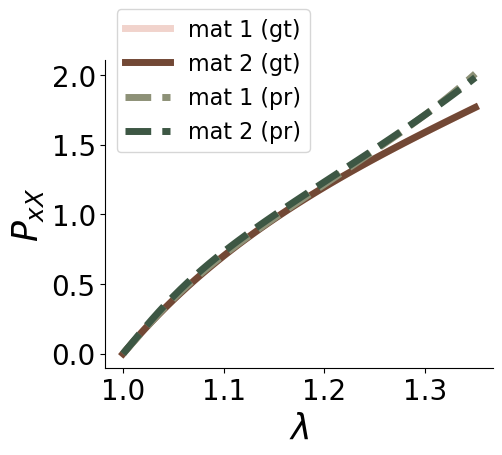

In [25]:
light_brown = "#f1d3cc"
dark_brown = "#724835"
light_green = "#8D9177" 
dark_green = "#3D5744"
point1=np.array([0.5, 0.3])
point2=np.array([0.5, 0.7])
mat1_params = coords_2_params_gt(point1)
mat2_params = coords_2_params_gt(point2)
mat1_P_gt = []
mat2_P_gt = []
mat1_P_pr = []
mat2_P_pr = []
# lmb_hist2 = [1.0, 1.005, 1.01, 1.02, 1.03, 1.04, 1.05, 1.10, 1.15, 1.20, 1.25, 1.30, 1.35]
lmb_hist2 = np.linspace(1,1.35)
for lmb in lmb_hist2:
    ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])
    mat1_P_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat1_params, 2)[0,0])
    mat2_P_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat2_params, 2)[0,0])

    mat1_params_pr = ff_nn(point1, Lambda_params)
    mat2_params_pr = ff_nn(point2, Lambda_params)
    mat1_P_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, mat1_params_pr, 2)[0,0])
    mat2_P_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, mat2_params_pr, 2)[0,0])

fig, ax = plt.subplots(figsize=(5,4))
ax.plot(lmb_hist2, mat1_P_gt,'-', label='mat 1 (gt)',color=light_brown, linewidth=5)
ax.plot(lmb_hist2, mat2_P_gt,'-', label='mat 2 (gt)',color=dark_brown, linewidth=5)

fig.gca().set_prop_cycle(None)
ax.plot(lmb_hist2, mat1_P_pr, '--', label='mat 1 (pr)',color=light_green , linewidth=5)
ax.plot(lmb_hist2, mat2_P_pr, '--', label='mat 2 (pr)',color=dark_green, linewidth=5)
ax.set_xlabel(r'$\lambda$',fontsize=25)
ax.set_ylabel(r'$P_{xX}$',fontsize=25)
ax.legend(fontsize=16, loc='upper left', bbox_to_anchor=(0, 1.20))
ax.set(xlabel='$\lambda$', ylabel='$P_{xX}$')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.tick_params(axis='both', labelsize=20)

In [ ]:
c_all = []
id=0
for lmb in lmb_hist:
    if id==id_for_plot:
        print(id)
        ugrad = jnp.array([[lmb - 1.0, 0.0],
                        [0.0,       lmb - 1.0]])

        params_gt = np.array([coords_2_params_gt(xy) for xy in elem_X])
        params_pr = ff_nn(elem_X, Lambda_params)

        for p_gt, p_pr in zip(params_gt, params_pr):
            c_gt = ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, p_gt, 2)[0, 0]
            c_pr = ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, p_pr, 2)[0, 0]
            c_all.append(c_gt)
            c_all.append(c_pr)
    id+=1
c_all = np.array(c_all)
c_range_50by50 = np.array([np.nanmin(c_all), np.nanmax(c_all)])

3


In [ ]:
with open('×_paper_post_weak_form_50_by_50_hyper_1_10_by_10_200samples.npy', 'rb') as f:
    mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))

In [ ]:
c_all = []
id=0
for lmb in lmb_hist:
    if id==id_for_plot:
        print(id)
        ugrad = jnp.array([[lmb - 1.0, 0.0],
                        [0.0,       lmb - 1.0]])

        params_gt = np.array([coords_2_params_gt(xy) for xy in elem_X])
        params_pr = ff_nn(elem_X, Lambda_params)

        for p_gt, p_pr in zip(params_gt, params_pr):
            c_gt = ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, p_gt, 2)[0, 0]
            c_pr = ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, p_pr, 2)[0, 0]
            c_all.append(c_gt)
            c_all.append(c_pr)
    id+=1
c_all = np.array(c_all)
c_range_10by10 = np.array([np.nanmin(c_all), np.nanmax(c_all)])

3


In [ ]:
with open('×_paper_post_weak_form_50_by_50_hyper_1_2_by_2_36samples.npy', 'rb') as f:
    mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))

In [ ]:
c_all = []
id=0
for lmb in lmb_hist:
    if id==id_for_plot:
        print(id)
        ugrad = jnp.array([[lmb - 1.0, 0.0],
                        [0.0,       lmb - 1.0]])

        params_gt = np.array([coords_2_params_gt(xy) for xy in elem_X])
        params_pr = ff_nn(elem_X, Lambda_params)

        for p_gt, p_pr in zip(params_gt, params_pr):
            c_gt = ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, p_gt, 2)[0, 0]
            c_pr = ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, p_pr, 2)[0, 0]
            c_all.append(c_gt)
            c_all.append(c_pr)
        
    id+=1
c_all = np.array(c_all)
c_range_2by2 = np.array([np.nanmin(c_all), np.nanmax(c_all)])

3


In [ ]:
all_ranges = np.stack([c_range_2by2, c_range_10by10, c_range_50by50])
global_min = np.min(all_ranges)
global_max = np.max(all_ranges)
print(global_min,global_max)

0.7139722169834278 1.375332566421627


In [ ]:
with open('×_paper_post_weak_form_50_by_50_hyper_1.npy', 'rb') as f:
    mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))

0
1
2
3


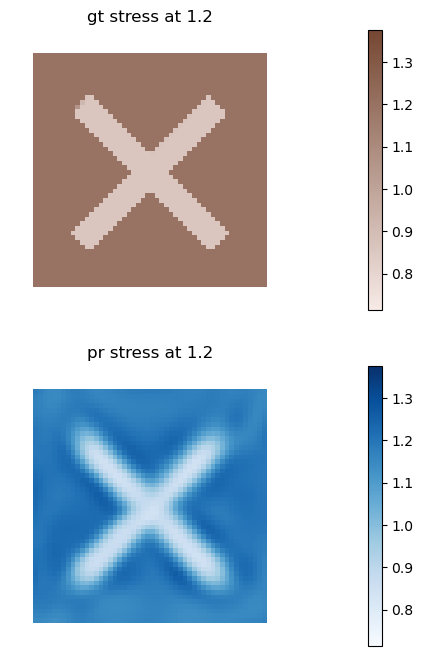

In [ ]:
# Stiffness across the domain
from matplotlib.colors import LinearSegmentedColormap
natural_brown_cmap = LinearSegmentedColormap.from_list(
    "natural_brown",
    [ "#f7eae7", "#754732" ],  # dark brown → light brown → pale peach
    N=256)
id=0
fig, axes = plt.subplots(2,1,figsize=(20,8))
for lmb in lmb_hist:
    print(id)
    if id==id_for_plot:
        ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])

        params_gt = []
        for xy in elem_X:
            params_gt.append(coords_2_params_gt(xy))
        params_gt = np.array(params_gt)
        params_pr = ff_nn(elem_X, Lambda_params)

        c_elem_gt = []
        c_elem_pr = []
        for params_gt_i, params_pr_i in zip(params_gt, params_pr):
            c_elem_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, params_gt_i, 2)[0,0])
            c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[0,0])
        
        plotmesh_updated(mesh.cells, mesh.points, c_elem_gt,global_min,global_max,title='gt stress at {}'.format(str(lmb)), ax=axes[0],ec='None',cmap=natural_brown_cmap); 
        extent = [np.min(c_elem_gt), np.max(c_elem_gt)]
        if extent[0] > np.min(c_elem_pr) and extent[1] < np.max(c_elem_pr):
            extend='both'
        elif extent[0] > np.min(c_elem_pr):
            extend='min'
        elif extent[1] < np.max(c_elem_pr):
            extend='max'
        plotmesh_updated(mesh.cells, mesh.points, c_elem_pr,global_min,global_max, title='pr stress at {}'.format(str(lmb)), ax=axes[1], ec='None'); 
    id+=1

In [ ]:
with open('×_paper_post_weak_form_50_by_50_hyper_1_10_by_10_200samples.npy', 'rb') as f:
    mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))

0
1
2
3


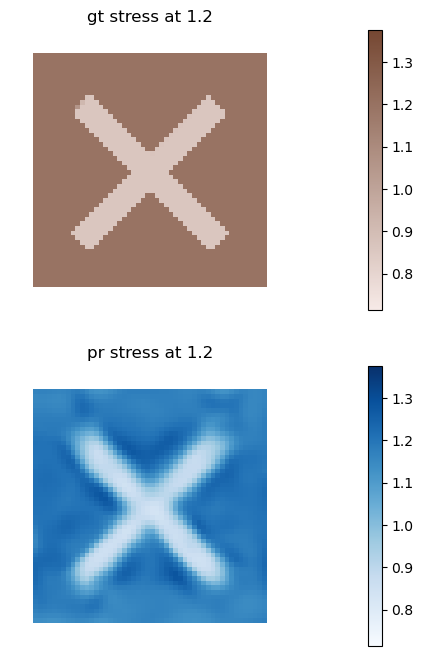

In [ ]:
# Stiffness across the domain
from matplotlib.colors import LinearSegmentedColormap
natural_brown_cmap = LinearSegmentedColormap.from_list(
    "natural_brown",
    [ "#f7eae7", "#754732" ],  # dark brown → light brown → pale peach
    N=256)
id=0
fig, axes = plt.subplots(2,1,figsize=(20,8))
for lmb in lmb_hist:
    print(id)
    if id==id_for_plot:
        ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])

        params_gt = []
        for xy in elem_X:
            params_gt.append(coords_2_params_gt(xy))
        params_gt = np.array(params_gt)
        params_pr = ff_nn(elem_X, Lambda_params)

        c_elem_gt = []
        c_elem_pr = []
        for params_gt_i, params_pr_i in zip(params_gt, params_pr):
            c_elem_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, params_gt_i, 2)[0,0])
            c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[0,0])
        
        plotmesh_updated(mesh.cells, mesh.points, c_elem_gt,global_min,global_max,title='gt stress at {}'.format(str(lmb)), ax=axes[0],ec='None',cmap=natural_brown_cmap); 
        extent = [np.min(c_elem_gt), np.max(c_elem_gt)]
        if extent[0] > np.min(c_elem_pr) and extent[1] < np.max(c_elem_pr):
            extend='both'
        elif extent[0] > np.min(c_elem_pr):
            extend='min'
        elif extent[1] < np.max(c_elem_pr):
            extend='max'
        plotmesh_updated(mesh.cells, mesh.points, c_elem_pr,global_min,global_max, title='pr stress at {}'.format(str(lmb)), ax=axes[1], ec='None'); 
    id+=1

In [ ]:
with open('×_paper_post_weak_form_50_by_50_hyper_1_2_by_2_36samples.npy', 'rb') as f:
    mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))

0
1
2
3


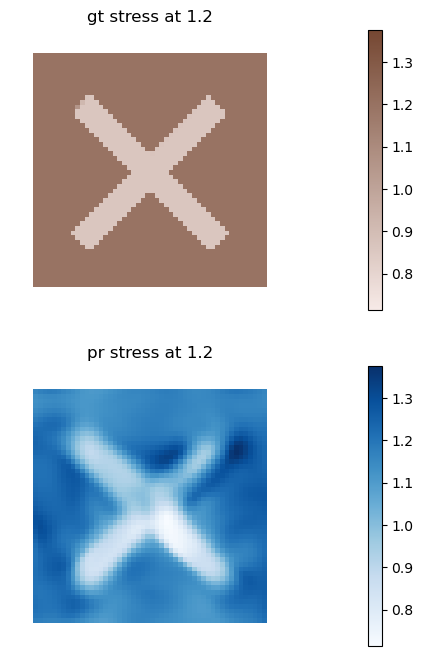

In [ ]:
# Stiffness across the domain
from matplotlib.colors import LinearSegmentedColormap
natural_brown_cmap = LinearSegmentedColormap.from_list(
    "natural_brown",
    [ "#f7eae7", "#754732" ],  # dark brown → light brown → pale peach
    N=256)
id=0
fig, axes = plt.subplots(2,1,figsize=(20,8))
for lmb in lmb_hist:
    print(id)
    if id==id_for_plot:
        ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])

        params_gt = []
        for xy in elem_X:
            params_gt.append(coords_2_params_gt(xy))
        params_gt = np.array(params_gt)
        params_pr = ff_nn(elem_X, Lambda_params)

        c_elem_gt = []
        c_elem_pr = []
        for params_gt_i, params_pr_i in zip(params_gt, params_pr):
            c_elem_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, params_gt_i, 2)[0,0])
            c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[0,0])
        
        plotmesh_updated(mesh.cells, mesh.points, c_elem_gt,global_min,global_max,title='gt stress at {}'.format(str(lmb)), ax=axes[0],ec='None',cmap=natural_brown_cmap); 
        extent = [np.min(c_elem_gt), np.max(c_elem_gt)]
        if extent[0] > np.min(c_elem_pr) and extent[1] < np.max(c_elem_pr):
            extend='both'
        elif extent[0] > np.min(c_elem_pr):
            extend='min'
        elif extent[1] < np.max(c_elem_pr):
            extend='max'
        plotmesh_updated(mesh.cells, mesh.points, c_elem_pr,global_min,global_max, title='pr stress at {}'.format(str(lmb)), ax=axes[1], ec='None'); 
    id+=1

In [ ]:
with open('×_paper_post_weak_form_50_by_50_hyper_1.npy', 'rb') as f:
    mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))

In [ ]:
c_gt_elem=[]
c_pr_elem=[]
id=0
for lmb in lmb_hist:
    if id==id_for_plot:
        print(id)
        ugrad = jnp.array([[lmb - 1.0, 0.0],
                        [0.0,       lmb - 1.0]])

        params_gt = np.array([coords_2_params_gt(xy) for xy in elem_X])
        params_pr = ff_nn(elem_X, Lambda_params)

        for p_gt, p_pr in zip(params_gt, params_pr):
            c_gt = ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, p_gt, 2)[0, 0]
            c_pr = ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, p_pr, 2)[0, 0]
            c_gt_elem.append(c_gt)
            c_pr_elem.append(c_pr)
    id+=1
c_gt_elem=np.array(c_gt_elem)
c_pr_elem=np.array(c_pr_elem)
c_L2_norm = np.linalg.norm(c_gt_elem[:,None]-c_pr_elem[:,None],axis=1)
c_range_50by50 = np.array([np.nanmin(c_L2_norm ), np.nanmax(c_L2_norm )])

3


In [ ]:
with open('×_paper_post_weak_form_50_by_50_hyper_1_10_by_10_200samples.npy', 'rb') as f:
    mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))

In [ ]:
c_gt_elem=[]
c_pr_elem=[]
id=0
for lmb in lmb_hist:
    if id==id_for_plot:
        print(id)
        ugrad = jnp.array([[lmb - 1.0, 0.0],
                        [0.0,       lmb - 1.0]])

        params_gt = np.array([coords_2_params_gt(xy) for xy in elem_X])
        params_pr = ff_nn(elem_X, Lambda_params)

        for p_gt, p_pr in zip(params_gt, params_pr):
            c_gt = ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, p_gt, 2)[0, 0]
            c_pr = ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, p_pr, 2)[0, 0]
            c_gt_elem.append(c_gt)
            c_pr_elem.append(c_pr)
    id+=1
c_gt_elem=np.array(c_gt_elem)
c_pr_elem=np.array(c_pr_elem)
c_L2_norm = np.linalg.norm(c_gt_elem[:,None]-c_pr_elem[:,None],axis=1)
c_range_10by10 = np.array([np.nanmin(c_L2_norm ), np.nanmax(c_L2_norm )])

3


In [ ]:
with open('×_paper_post_weak_form_50_by_50_hyper_1_2_by_2_36samples.npy', 'rb') as f:
    mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))

In [ ]:
c_gt_elem=[]
c_pr_elem=[]
id=0
for lmb in lmb_hist:
    if id==id_for_plot:
        print(id)
        ugrad = jnp.array([[lmb - 1.0, 0.0],
                        [0.0,       lmb - 1.0]])

        params_gt = np.array([coords_2_params_gt(xy) for xy in elem_X])
        params_pr = ff_nn(elem_X, Lambda_params)

        for p_gt, p_pr in zip(params_gt, params_pr):
            c_gt = ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, p_gt, 2)[0, 0]
            c_pr = ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, p_pr, 2)[0, 0]
            c_gt_elem.append(c_gt)
            c_pr_elem.append(c_pr)
    id+=1
c_gt_elem=np.array(c_gt_elem)
c_pr_elem=np.array(c_pr_elem)
c_L2_norm = np.linalg.norm(c_gt_elem[:,None]-c_pr_elem[:,None],axis=1)
c_range_2by2 = np.array([np.nanmin(c_L2_norm ), np.nanmax(c_L2_norm )])

3


In [ ]:
all_ranges = np.stack([c_range_2by2, c_range_10by10, c_range_50by50])
global_min = np.min(all_ranges)
global_max = np.max(all_ranges)
print(global_min,global_max)

4.4810364345782006e-06 0.3608964301673706


In [ ]:
with open('×_paper_post_weak_form_50_by_50_hyper_1.npy', 'rb') as f:
    mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))

0
1
2
3


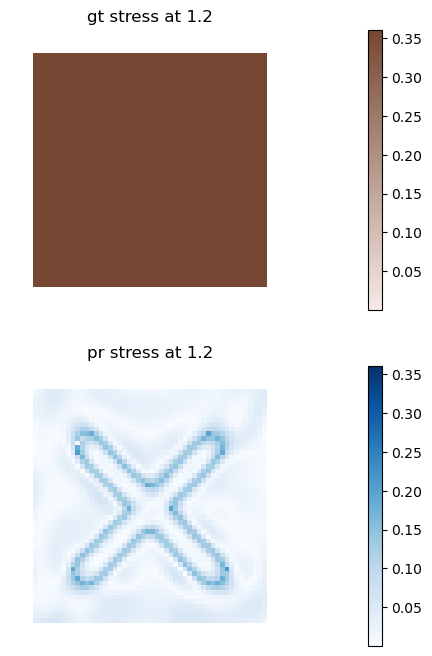

In [ ]:
# Stiffness across the domain
from matplotlib.colors import LinearSegmentedColormap
natural_brown_cmap = LinearSegmentedColormap.from_list(
    "natural_brown",
    [ "#f7eae7", "#754732" ],  # dark brown → light brown → pale peach
    N=256)
id=0
fig, axes = plt.subplots(2,1,figsize=(20,8))
for lmb in lmb_hist:
    print(id)
    if id==id_for_plot:
        ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])

        params_gt = []
        for xy in elem_X:
            params_gt.append(coords_2_params_gt(xy))
        params_gt = np.array(params_gt)
        params_pr = ff_nn(elem_X, Lambda_params)

        c_elem_gt = []
        c_elem_pr = []
        for params_gt_i, params_pr_i in zip(params_gt, params_pr):
            c_elem_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, params_gt_i, 2)[0,0])
            c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[0,0])
        
        plotmesh_updated(mesh.cells, mesh.points, c_elem_gt,global_min,global_max,title='gt stress at {}'.format(str(lmb)), ax=axes[0],ec='None',cmap=natural_brown_cmap); 
        extent = [np.min(c_elem_gt), np.max(c_elem_gt)]
        if extent[0] > np.min(c_elem_pr) and extent[1] < np.max(c_elem_pr):
            extend='both'
        elif extent[0] > np.min(c_elem_pr):
            extend='min'
        elif extent[1] < np.max(c_elem_pr):
            extend='max'
        c_L2_norm_50by50 = np.linalg.norm(np.array(c_elem_gt)[:,None]-np.array(c_elem_pr)[:,None],axis=1)
        plotmesh_updated(mesh.cells, mesh.points, c_L2_norm_50by50 ,global_min,global_max, title='pr stress at {}'.format(str(lmb)), ax=axes[1], ec='None'); 
    id+=1

In [ ]:
with open('×_paper_post_weak_form_50_by_50_hyper_1_10_by_10_200samples.npy', 'rb') as f:
    mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))

0
1
2
3


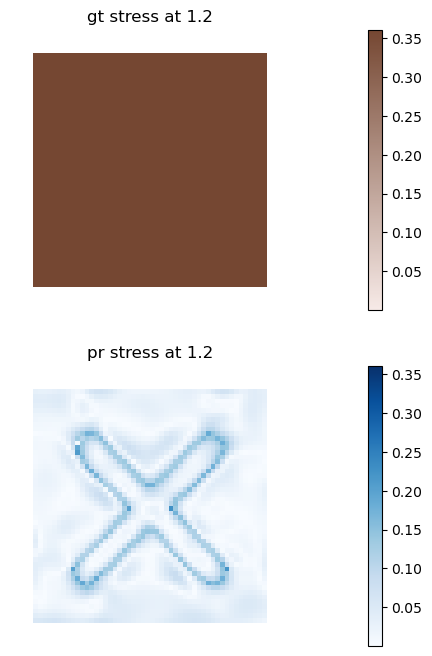

In [ ]:
# Stiffness across the domain
from matplotlib.colors import LinearSegmentedColormap
natural_brown_cmap = LinearSegmentedColormap.from_list(
    "natural_brown",
    [ "#f7eae7", "#754732" ],  # dark brown → light brown → pale peach
    N=256)
id=0
fig, axes = plt.subplots(2,1,figsize=(20,8))
for lmb in lmb_hist:
    print(id)
    if id==id_for_plot:
        ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])

        params_gt = []
        for xy in elem_X:
            params_gt.append(coords_2_params_gt(xy))
        params_gt = np.array(params_gt)
        params_pr = ff_nn(elem_X, Lambda_params)

        c_elem_gt = []
        c_elem_pr = []
        for params_gt_i, params_pr_i in zip(params_gt, params_pr):
            c_elem_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, params_gt_i, 2)[0,0])
            c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[0,0])
        
        plotmesh_updated(mesh.cells, mesh.points, c_elem_gt,global_min,global_max,title='gt stress at {}'.format(str(lmb)), ax=axes[0],ec='None',cmap=natural_brown_cmap); 
        extent = [np.min(c_elem_gt), np.max(c_elem_gt)]
        if extent[0] > np.min(c_elem_pr) and extent[1] < np.max(c_elem_pr):
            extend='both'
        elif extent[0] > np.min(c_elem_pr):
            extend='min'
        elif extent[1] < np.max(c_elem_pr):
            extend='max'
        c_L2_norm_10by10 = np.linalg.norm(np.array(c_elem_gt)[:,None]-np.array(c_elem_pr)[:,None],axis=1)
        plotmesh_updated(mesh.cells, mesh.points, c_L2_norm_10by10 ,global_min,global_max, title='pr stress at {}'.format(str(lmb)), ax=axes[1], ec='None'); 
    id+=1

In [ ]:
with open('×_paper_post_weak_form_50_by_50_hyper_1_2_by_2_36samples.npy', 'rb') as f:
    mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))

0
1
2
3


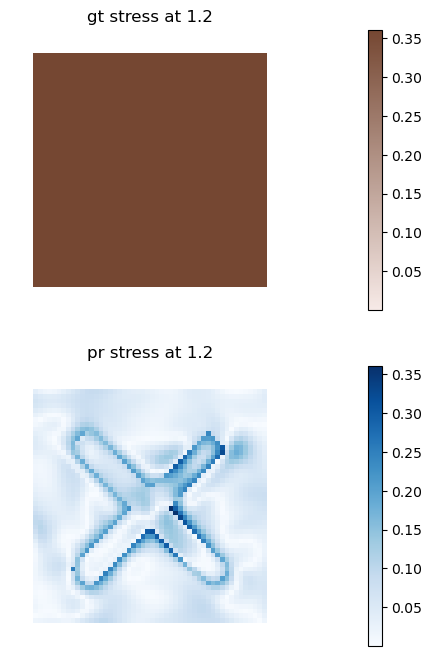

In [ ]:
# Stiffness across the domain
from matplotlib.colors import LinearSegmentedColormap
natural_brown_cmap = LinearSegmentedColormap.from_list(
    "natural_brown",
    [ "#f7eae7", "#754732" ],  # dark brown → light brown → pale peach
    N=256)
id=0
fig, axes = plt.subplots(2,1,figsize=(20,8))
for lmb in lmb_hist:
    print(id)
    if id==id_for_plot:
        ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])

        params_gt = []
        for xy in elem_X:
            params_gt.append(coords_2_params_gt(xy))
        params_gt = np.array(params_gt)
        params_pr = ff_nn(elem_X, Lambda_params)

        c_elem_gt = []
        c_elem_pr = []
        for params_gt_i, params_pr_i in zip(params_gt, params_pr):
            c_elem_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, params_gt_i, 2)[0,0])
            c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[0,0])
        
        plotmesh_updated(mesh.cells, mesh.points, c_elem_gt,global_min,global_max,title='gt stress at {}'.format(str(lmb)), ax=axes[0],ec='None',cmap=natural_brown_cmap); 
        extent = [np.min(c_elem_gt), np.max(c_elem_gt)]
        if extent[0] > np.min(c_elem_pr) and extent[1] < np.max(c_elem_pr):
            extend='both'
        elif extent[0] > np.min(c_elem_pr):
            extend='min'
        elif extent[1] < np.max(c_elem_pr):
            extend='max'
        c_L2_norm_2by2 = np.linalg.norm(np.array(c_elem_gt)[:,None]-np.array(c_elem_pr)[:,None],axis=1)
        plotmesh_updated(mesh.cells, mesh.points, c_L2_norm_2by2 ,global_min,global_max, title='pr stress at {}'.format(str(lmb)), ax=axes[1], ec='None'); 
    id+=1

In [ ]:
with open('×_paper_post.npy', 'rb') as f:
    mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))

In [ ]:
c_all = []
id=0
for lmb in lmb_hist:
    if id==id_for_plot:
        print(id)
        ugrad = jnp.array([[lmb - 1.0, 0.0],
                        [0.0,       lmb - 1.0]])

        params_gt = np.array([coords_2_params_gt(xy) for xy in elem_X])
        params_pr = ff_nn(elem_X, Lambda_params)

        for p_gt, p_pr in zip(params_gt, params_pr):
            c_gt = ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, p_gt, 2)[0, 0]
            c_pr = ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, p_pr, 2)[0, 0]
            c_all.append(c_gt)
            c_all.append(c_pr)
    id+=1
c_all = np.array(c_all)
c_range_strong = np.array([np.nanmin(c_all), np.nanmax(c_all)])

3


In [ ]:
print(c_range_strong )

[0.82054 1.24955]


0
1
2
3


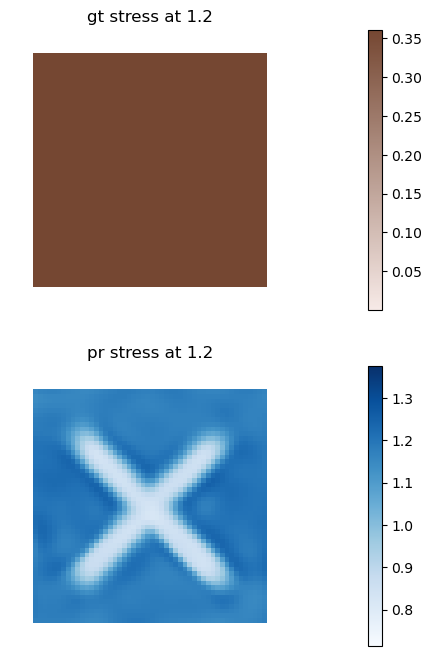

In [ ]:
# Stiffness across the domain
from matplotlib.colors import LinearSegmentedColormap
natural_brown_cmap = LinearSegmentedColormap.from_list(
    "natural_brown",
    [ "#f7eae7", "#754732" ],  # dark brown → light brown → pale peach
    N=256)
id=0
fig, axes = plt.subplots(2,1,figsize=(20,8))
for lmb in lmb_hist:
    print(id)
    if id==id_for_plot:
        ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])

        params_gt = []
        for xy in elem_X:
            params_gt.append(coords_2_params_gt(xy))
        params_gt = np.array(params_gt)
        params_pr = ff_nn(elem_X, Lambda_params)

        c_elem_gt = []
        c_elem_pr = []
        for params_gt_i, params_pr_i in zip(params_gt, params_pr):
            c_elem_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, params_gt_i, 2)[0,0])
            c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[0,0])
        
        plotmesh_updated(mesh.cells, mesh.points, c_elem_gt,global_min,global_max,title='gt stress at {}'.format(str(lmb)), ax=axes[0],ec='None',cmap=natural_brown_cmap); 
        extent = [np.min(c_elem_gt), np.max(c_elem_gt)]
        if extent[0] > np.min(c_elem_pr) and extent[1] < np.max(c_elem_pr):
            extend='both'
        elif extent[0] > np.min(c_elem_pr):
            extend='min'
        elif extent[1] < np.max(c_elem_pr):
            extend='max'
        plotmesh_updated(mesh.cells, mesh.points, c_elem_pr,0.7139722169834278, 1.375332566421627, title='pr stress at {}'.format(str(lmb)), ax=axes[1], ec='None'); 
    id+=1

In [ ]:
c_gt_elem=[]
c_pr_elem=[]
id=0
for lmb in lmb_hist:
    if id==id_for_plot:
        print(id)
        ugrad = jnp.array([[lmb - 1.0, 0.0],
                        [0.0,       lmb - 1.0]])

        params_gt = np.array([coords_2_params_gt(xy) for xy in elem_X])
        params_pr = ff_nn(elem_X, Lambda_params)

        for p_gt, p_pr in zip(params_gt, params_pr):
            c_gt = ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, p_gt, 2)[0, 0]
            c_pr = ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, p_pr, 2)[0, 0]
            c_gt_elem.append(c_gt)
            c_pr_elem.append(c_pr)
    id+=1
c_gt_elem=np.array(c_gt_elem)
c_pr_elem=np.array(c_pr_elem)
c_L2_norm = np.linalg.norm(c_gt_elem[:,None]-c_pr_elem[:,None],axis=1)
c_range_strong = np.array([np.nanmin(c_L2_norm ), np.nanmax(c_L2_norm )])

3


In [ ]:
c_range_strong 

array([0.     , 0.21249])

0
1
2
3


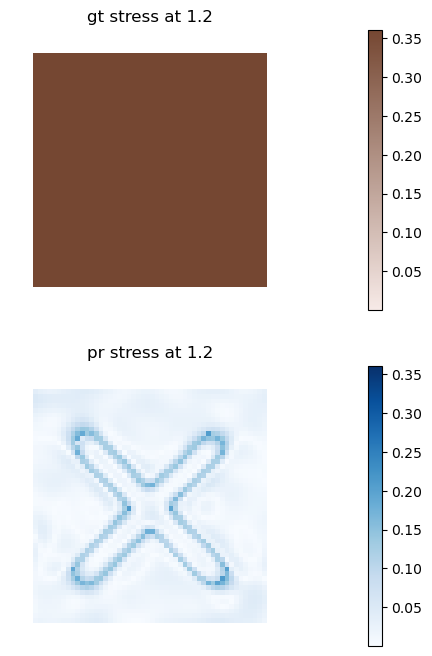

In [ ]:
# Stiffness across the domain
from matplotlib.colors import LinearSegmentedColormap
natural_brown_cmap = LinearSegmentedColormap.from_list(
    "natural_brown",
    [ "#f7eae7", "#754732" ],  # dark brown → light brown → pale peach
    N=256)
id=0
fig, axes = plt.subplots(2,1,figsize=(20,8))
for lmb in lmb_hist:
    print(id)
    if id==id_for_plot:
        ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])

        params_gt = []
        for xy in elem_X:
            params_gt.append(coords_2_params_gt(xy))
        params_gt = np.array(params_gt)
        params_pr = ff_nn(elem_X, Lambda_params)

        c_elem_gt = []
        c_elem_pr = []
        for params_gt_i, params_pr_i in zip(params_gt, params_pr):
            c_elem_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, params_gt_i, 2)[0,0])
            c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[0,0])
        
        plotmesh_updated(mesh.cells, mesh.points, c_elem_gt,global_min,global_max,title='gt stress at {}'.format(str(lmb)), ax=axes[0],ec='None',cmap=natural_brown_cmap); 
        extent = [np.min(c_elem_gt), np.max(c_elem_gt)]
        if extent[0] > np.min(c_elem_pr) and extent[1] < np.max(c_elem_pr):
            extend='both'
        elif extent[0] > np.min(c_elem_pr):
            extend='min'
        elif extent[1] < np.max(c_elem_pr):
            extend='max'
        c_L2_norm_strong = np.linalg.norm(np.array(c_elem_gt)[:,None]-np.array(c_elem_pr)[:,None],axis=1)
        plotmesh_updated(mesh.cells, mesh.points, c_L2_norm_strong ,4.4810364345782006e-06 ,0.3608964301673706
, title='pr stress at {}'.format(str(lmb)), ax=axes[1], ec='None'); 
    id+=1

### Plotting equilibrium

In [ ]:
def get_P(X, Y, t, Lambda_params, coord_2_strain_params, model):
    F_xx, F_xy, F_yx, F_yy = coords_2_strain_nn_ff(jnp.array([X,Y,t])[None,:], coord_2_strain_params).flatten()
    # get NODE individual-specific params, phi, from the Lambda NN
    Lambda_inp = jnp.array([X,Y]).reshape([-1,2])
    phi = ff_nn_ff(Lambda_inp, Lambda_params).flatten()
    # Make predictions with this NODE
    ugrad = jnp.array([[F_xx-1.0, F_xy],[F_yx, F_yy-1.0]])
    P = ThreeDElasticity(model).ugrad_2_P(ugrad, phi, 2)
    return P[0,0], P[1,0], P[0,1], P[1,1]
get_P_vmap = vmap(get_P, in_axes=(0,0,0,None,None,None), out_axes=(0,0,0,0))

get_Pxx = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[0]
get_Pyx = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[1]
get_Pxy = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[2]
get_Pyy = lambda X, Y, t, a, b, c: get_P(X, Y, t, a, b, c)[3]

Grad_Pxx_X = vmap(grad(get_Pxx, argnums=0), in_axes=(0,0,0,None,None,None), out_axes=0) # should return dsgm_xx/dx
Grad_Pyx_X = vmap(grad(get_Pyx, argnums=0), in_axes=(0,0,0,None,None,None), out_axes=0)
Grad_Pxy_Y = vmap(grad(get_Pyx, argnums=1), in_axes=(0,0,0,None,None,None), out_axes=0)
Grad_Pyy_Y = vmap(grad(get_Pyy, argnums=1), in_axes=(0,0,0,None,None,None), out_axes=0)
@partial(jit, static_argnums=(3,))
def divergence(Lambda_params, XYt, c2s_params, model):
    dPxx_dX = Grad_Pxx_X(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPxy_dY = Grad_Pxy_Y(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPyx_dX = Grad_Pyx_X(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    dPyy_dY = Grad_Pyy_Y(XYt[:,0], XYt[:,1], XYt[:,2], Lambda_params, c2s_params, model)
    
    Div_X = dPxx_dX + dPxy_dY
    Div_Y = dPyx_dX + dPyy_dY
    return Div_X, Div_Y

In [ ]:
with open('×_paper_post_weak_form_50_by_50_hyper_1.npy', 'rb') as f:
    mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))

In [ ]:
# Stiffness across the domain
c_elem_pr=[]
from matplotlib.colors import LinearSegmentedColormap
natural_brown_cmap = LinearSegmentedColormap.from_list(
    "natural_brown",
    [ "#f7eae7", "#754732" ],  # dark brown → light brown → pale peach
    N=256)
id=0
for lmb in lmb_hist:
    if id==id_for_plot:
        # params_gt = np.array(params_gt)
        # params_pr = ff_nn(elem_X, Lambda_params)
        XYt = jnp.hstack((elem_X, id_for_plot * jnp.ones_like(elem_X[:, :1])))
        #print(len(params_pr))
        Div_X, Div_Y=divergence(Lambda_params,XYt,coord_2_strain_params, NODE_w_unravel)
        c_elem_pr.append(np.linalg.norm(Div_X[:,None]**2+Div_Y[:,None]**2,axis=1))
    id+=1
c_range_50by50 = np.array([np.nanmin(c_elem_pr), np.nanmax(c_elem_pr)])

In [ ]:
with open('×_paper_post_weak_form_50_by_50_hyper_1_10_by_10_200samples.npy', 'rb') as f:
    mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))

In [ ]:
# Stiffness across the domain
c_elem_pr=[]
from matplotlib.colors import LinearSegmentedColormap
natural_brown_cmap = LinearSegmentedColormap.from_list(
    "natural_brown",
    [ "#f7eae7", "#754732" ],  # dark brown → light brown → pale peach
    N=256)
id=0
for lmb in lmb_hist:
    if id==id_for_plot:
        # params_gt = np.array(params_gt)
        # params_pr = ff_nn(elem_X, Lambda_params)
        XYt = jnp.hstack((elem_X, id_for_plot * jnp.ones_like(elem_X[:, :1])))
        #print(len(params_pr))
        Div_X, Div_Y=divergence(Lambda_params,XYt,coord_2_strain_params, NODE_w_unravel)
        c_elem_pr.append(np.linalg.norm(Div_X[:,None]**2+Div_Y[:,None]**2,axis=1))
    id+=1
c_range_10by10 = np.array([np.nanmin(c_elem_pr), np.nanmax(c_elem_pr)])

In [ ]:
with open('×_paper_post_weak_form_50_by_50_hyper_1_2_by_2_36samples.npy', 'rb') as f:
    mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))

In [ ]:
# Stiffness across the domain
c_elem_pr=[]
from matplotlib.colors import LinearSegmentedColormap
natural_brown_cmap = LinearSegmentedColormap.from_list(
    "natural_brown",
    [ "#f7eae7", "#754732" ],  # dark brown → light brown → pale peach
    N=256)
id=0
for lmb in lmb_hist:
    if id==id_for_plot:
        # params_gt = np.array(params_gt)
        # params_pr = ff_nn(elem_X, Lambda_params)
        XYt = jnp.hstack((elem_X, id_for_plot * jnp.ones_like(elem_X[:, :1])))
        #print(len(params_pr))
        Div_X, Div_Y=divergence(Lambda_params,XYt,coord_2_strain_params, NODE_w_unravel)
        c_elem_pr.append(np.linalg.norm(Div_X[:,None]**2+Div_Y[:,None]**2,axis=1))
    id+=1
c_range_2by2 = np.array([np.nanmin(c_elem_pr), np.nanmax(c_elem_pr)])

In [ ]:
with open('×_paper_post.npy', 'rb') as f:
    mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))

In [ ]:
# Stiffness across the domain
c_elem_pr=[]
from matplotlib.colors import LinearSegmentedColormap
natural_brown_cmap = LinearSegmentedColormap.from_list(
    "natural_brown",
    [ "#f7eae7", "#754732" ],  # dark brown → light brown → pale peach
    N=256)
id=0
for lmb in lmb_hist:
    if id==id_for_plot:
        # params_gt = np.array(params_gt)
        # params_pr = ff_nn(elem_X, Lambda_params)
        XYt = jnp.hstack((elem_X, id_for_plot * jnp.ones_like(elem_X[:, :1])))
        #print(len(params_pr))
        Div_X, Div_Y=divergence(Lambda_params,XYt,coord_2_strain_params, NODE_w_unravel)
        c_elem_pr.append(np.linalg.norm(Div_X[:,None]**2+Div_Y[:,None]**2,axis=1))
    id+=1
c_range_strong = np.array([np.nanmin(c_elem_pr), np.nanmax(c_elem_pr)])

In [ ]:
all_ranges = np.stack([c_range_2by2, c_range_10by10, c_range_50by50,c_range_strong])
global_min = np.min(all_ranges)
global_max = np.max(all_ranges)
print(global_min,global_max)

2.52777769567443e-06 35.85591749774912


In [ ]:
with open('×_paper_post_weak_form_50_by_50_hyper_1.npy', 'rb') as f:
    mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))

0
1
2
3
(1, 2500)


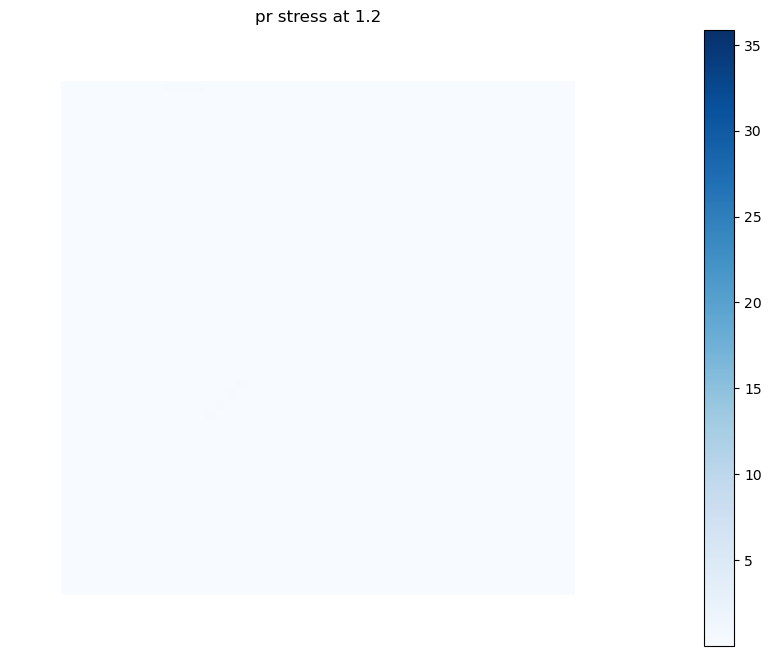

In [ ]:
# Stiffness across the domain
from matplotlib.colors import LinearSegmentedColormap
natural_brown_cmap = LinearSegmentedColormap.from_list(
    "natural_brown",
    [ "#f7eae7", "#754732" ],  # dark brown → light brown → pale peach
    N=256)
c_elem_pr=[]
fig, ax = plt.subplots(figsize=(20, 8))
id=0
for lmb in lmb_hist:
    print(id)
    if id==id_for_plot:
       XYt = jnp.hstack((elem_X, id_for_plot * jnp.ones_like(elem_X[:, :1])))
       Div_X, Div_Y=divergence(Lambda_params,XYt,coord_2_strain_params, NODE_w_unravel)
       c_elem_pr.append(np.linalg.norm(Div_X[:,None]**2+Div_Y[:,None]**2,axis=1))
       plotmesh_updated(mesh.cells, mesh.points, np.array(c_elem_pr).squeeze(),global_min,global_max, title='pr stress at {}'.format(str(lmb)), ax=ax, ec='None'); 
    id+=1

In [ ]:
with open('×_paper_post_weak_form_50_by_50_hyper_1_10_by_10_200samples.npy', 'rb') as f:
    mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))

0
1
2
3


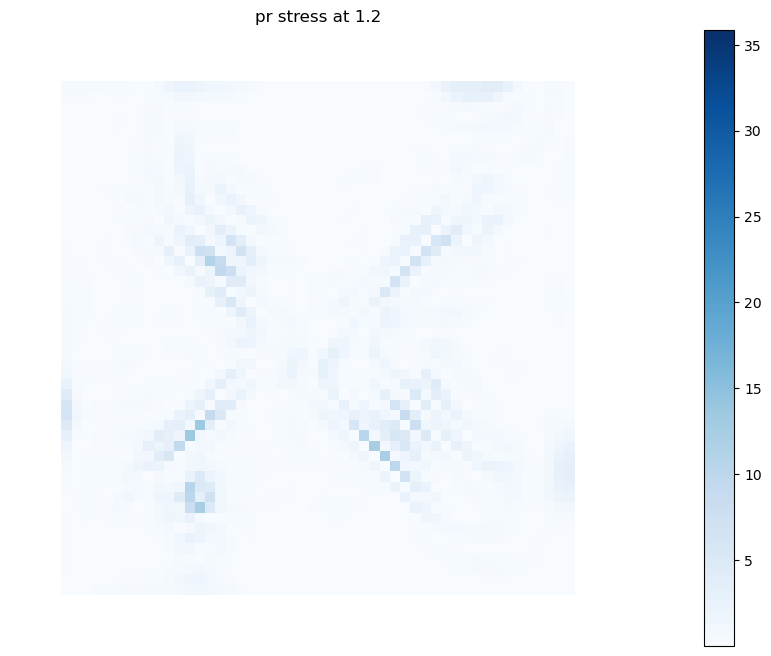

In [ ]:
# Stiffness across the domain
from matplotlib.colors import LinearSegmentedColormap
natural_brown_cmap = LinearSegmentedColormap.from_list(
    "natural_brown",
    [ "#f7eae7", "#754732" ],  # dark brown → light brown → pale peach
    N=256)
c_elem_pr=[]
fig, ax = plt.subplots(figsize=(20, 8))
id=0
for lmb in lmb_hist:
    print(id)
    if id==id_for_plot:
       XYt = jnp.hstack((elem_X, id_for_plot * jnp.ones_like(elem_X[:, :1])))
       Div_X, Div_Y=divergence(Lambda_params,XYt,coord_2_strain_params, NODE_w_unravel)
       c_elem_pr.append(np.linalg.norm(Div_X[:,None]**2+Div_Y[:,None]**2,axis=1))
       plotmesh_updated(mesh.cells, mesh.points, np.array(c_elem_pr).squeeze(),global_min,global_max, title='pr stress at {}'.format(str(lmb)), ax=ax, ec='None'); 
    id+=1

In [ ]:
with open('×_paper_post_weak_form_50_by_50_hyper_1_2_by_2_36samples.npy', 'rb') as f:
    mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))

0
1
2
3


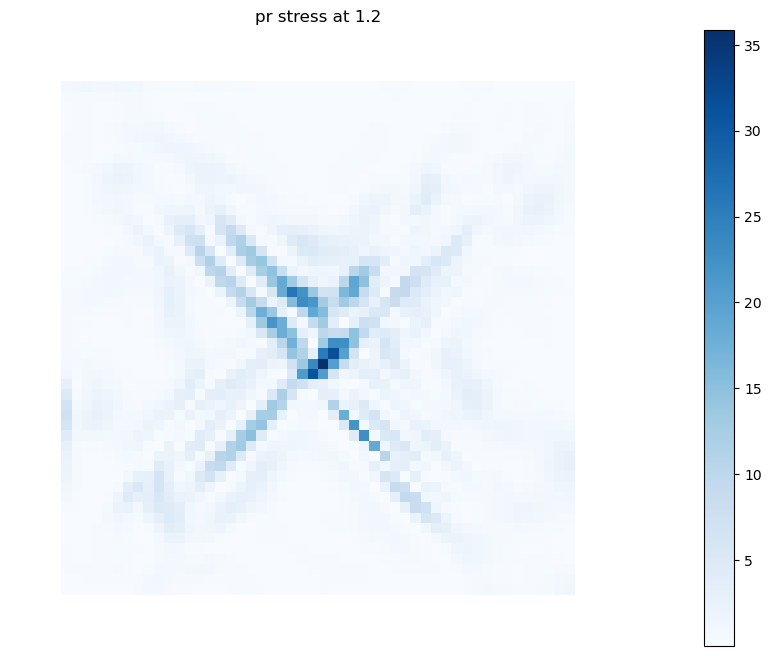

In [ ]:
# Stiffness across the domain
from matplotlib.colors import LinearSegmentedColormap
natural_brown_cmap = LinearSegmentedColormap.from_list(
    "natural_brown",
    [ "#f7eae7", "#754732" ],  # dark brown → light brown → pale peach
    N=256)
c_elem_pr=[]
fig, ax = plt.subplots(figsize=(20, 8))
id=0
for lmb in lmb_hist:
    print(id)
    if id==id_for_plot:
       XYt = jnp.hstack((elem_X, id_for_plot * jnp.ones_like(elem_X[:, :1])))
       Div_X, Div_Y=divergence(Lambda_params,XYt,coord_2_strain_params, NODE_w_unravel)
       c_elem_pr.append(np.linalg.norm(Div_X[:,None]**2+Div_Y[:,None]**2,axis=1))
       plotmesh_updated(mesh.cells, mesh.points, np.array(c_elem_pr).squeeze(),global_min,global_max, title='pr stress at {}'.format(str(lmb)), ax=ax, ec='None'); 
    id+=1

In [ ]:
with open('×_paper_post.npy', 'rb') as f:
    mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))

0
1
2
3


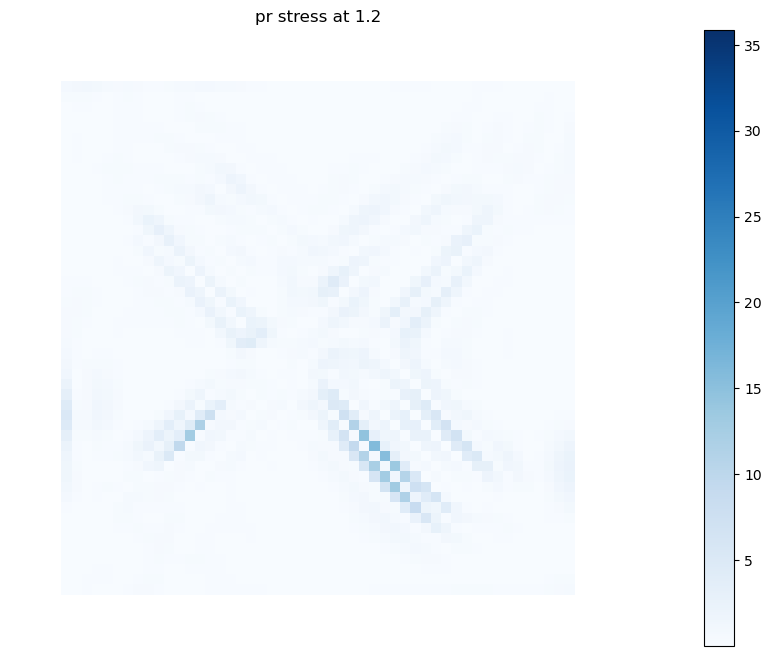

In [ ]:
# Stiffness across the domain
from matplotlib.colors import LinearSegmentedColormap
natural_brown_cmap = LinearSegmentedColormap.from_list(
    "natural_brown",
    [ "#f7eae7", "#754732" ],  # dark brown → light brown → pale peach
    N=256)
c_elem_pr=[]
fig, ax = plt.subplots(figsize=(20, 8))
id=0
for lmb in lmb_hist:
    print(id)
    if id==id_for_plot:
       XYt = jnp.hstack((elem_X, id_for_plot * jnp.ones_like(elem_X[:, :1])))
       Div_X, Div_Y=divergence(Lambda_params,XYt,coord_2_strain_params, NODE_w_unravel)
       c_elem_pr.append(np.linalg.norm(Div_X[:,None]**2+Div_Y[:,None]**2,axis=1))
       plotmesh_updated(mesh.cells, mesh.points, np.array(c_elem_pr).squeeze(),global_min,global_max, title='pr stress at {}'.format(str(lmb)), ax=ax, ec='None'); 
    id+=1

##### 50_by_50

In [ ]:
with open('×_paper_post_weak_form_50_by_50_hyper_1.npy', 'rb') as f:
    mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))

In [ ]:
mat1_params = coords_2_params_gt([0.0,0.0])
mat2_params = coords_2_params_gt([0.5,0.5])
mat1_P_gt = []
mat2_P_gt = []
mat1_P_pr = []
mat2_P_pr = []
# lmb_hist2 = [1.0, 1.005, 1.01, 1.02, 1.03, 1.04, 1.05, 1.10, 1.15, 1.20, 1.25, 1.30, 1.35]
lmb_hist2 = np.linspace(1,1.35)
for lmb in lmb_hist2:
    ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])
    mat1_P_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat1_params, 2)[0,0])
    mat2_P_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat2_params, 2)[0,0])

    mat1_params_pr = ff_nn(np.array([0.0, 0.0]), Lambda_params)
    mat2_params_pr = ff_nn(np.array([0.5, 0.5]), Lambda_params)
    mat1_P_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, mat1_params_pr, 2)[0,0])
    mat2_P_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, mat2_params_pr, 2)[0,0])

fig, ax = plt.subplots(figsize=(5,4))
ax.plot(lmb_hist2, mat1_P_gt, label='mat 1 (gt)')
ax.plot(lmb_hist2, mat2_P_gt, label='mat 2 (gt)')

fig.gca().set_prop_cycle(None)
ax.plot(lmb_hist2, mat1_P_pr, '--', label='mat 1 (pr)')
ax.plot(lmb_hist2, mat2_P_pr, '--', label='mat 2 (pr)')

ax.legend()
ax.set(xlabel='$\lambda$', ylabel='$P_{xx}$')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

#### 20_by_20

In [ ]:
with open('×_paper_post_weak_form_50_by_50_hyper_1_20_by_20.npy', 'rb') as f:
    mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))

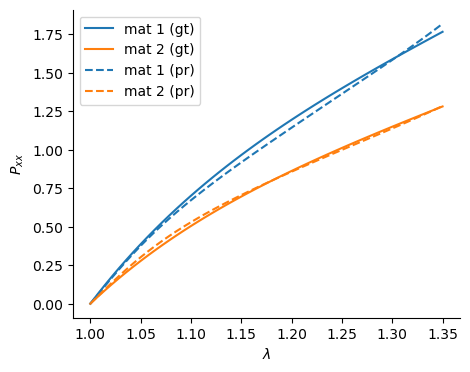

In [ ]:
mat1_params = coords_2_params_gt([0.0,0.0])
mat2_params = coords_2_params_gt([0.5,0.5])
mat1_P_gt = []
mat2_P_gt = []
mat1_P_pr = []
mat2_P_pr = []
# lmb_hist2 = [1.0, 1.005, 1.01, 1.02, 1.03, 1.04, 1.05, 1.10, 1.15, 1.20, 1.25, 1.30, 1.35]
lmb_hist2 = np.linspace(1,1.35)
for lmb in lmb_hist2:
    ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])
    mat1_P_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat1_params, 2)[0,0])
    mat2_P_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat2_params, 2)[0,0])

    mat1_params_pr = ff_nn(np.array([0.0, 0.0]), Lambda_params)
    mat2_params_pr = ff_nn(np.array([0.5, 0.5]), Lambda_params)
    mat1_P_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, mat1_params_pr, 2)[0,0])
    mat2_P_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, mat2_params_pr, 2)[0,0])

fig, ax = plt.subplots(figsize=(5,4))
ax.plot(lmb_hist2, mat1_P_gt, label='mat 1 (gt)')
ax.plot(lmb_hist2, mat2_P_gt, label='mat 2 (gt)')

fig.gca().set_prop_cycle(None)
ax.plot(lmb_hist2, mat1_P_pr, '--', label='mat 1 (pr)')
ax.plot(lmb_hist2, mat2_P_pr, '--', label='mat 2 (pr)')

ax.legend()
ax.set(xlabel='$\lambda$', ylabel='$P_{xx}$')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

In [ ]:
# Stiffness across the domain
from matplotlib.colors import LinearSegmentedColormap
natural_brown_cmap = LinearSegmentedColormap.from_list(
    "natural_brown",
    [ "#f7eae7", "#754732" ],  # dark brown → light brown → pale peach
    N=256)
fig, axes = plt.subplots(2,4,figsize=(20,8))
for lmb, ax in zip(lmb_hist, axes.T):
    ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])

    params_gt = []
    for xy in elem_X:
        params_gt.append(coords_2_params_gt(xy))
    params_gt = np.array(params_gt)
    params_pr = ff_nn(elem_X, Lambda_params)

    c_elem_gt = []
    c_elem_pr = []
    for params_gt_i, params_pr_i in zip(params_gt, params_pr):
        c_elem_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, params_gt_i, 2)[0,0])
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[0,0])
    
    plotmesh(mesh.cells, mesh.points, c_elem_gt, title='gt stress at {}'.format(str(lmb)), ax=ax[0],ec='None',cmap=natural_brown_cmap); 
    extent = [np.min(c_elem_gt), np.max(c_elem_gt)]
    if extent[0] > np.min(c_elem_pr) and extent[1] < np.max(c_elem_pr):
        extend='both'
    elif extent[0] > np.min(c_elem_pr):
        extend='min'
    elif extent[1] < np.max(c_elem_pr):
        extend='max'
    plotmesh(mesh.cells, mesh.points, c_elem_pr, title='pr stress at {}'.format(str(lmb)), ax=ax[1], extent=extent, ec='None'); 

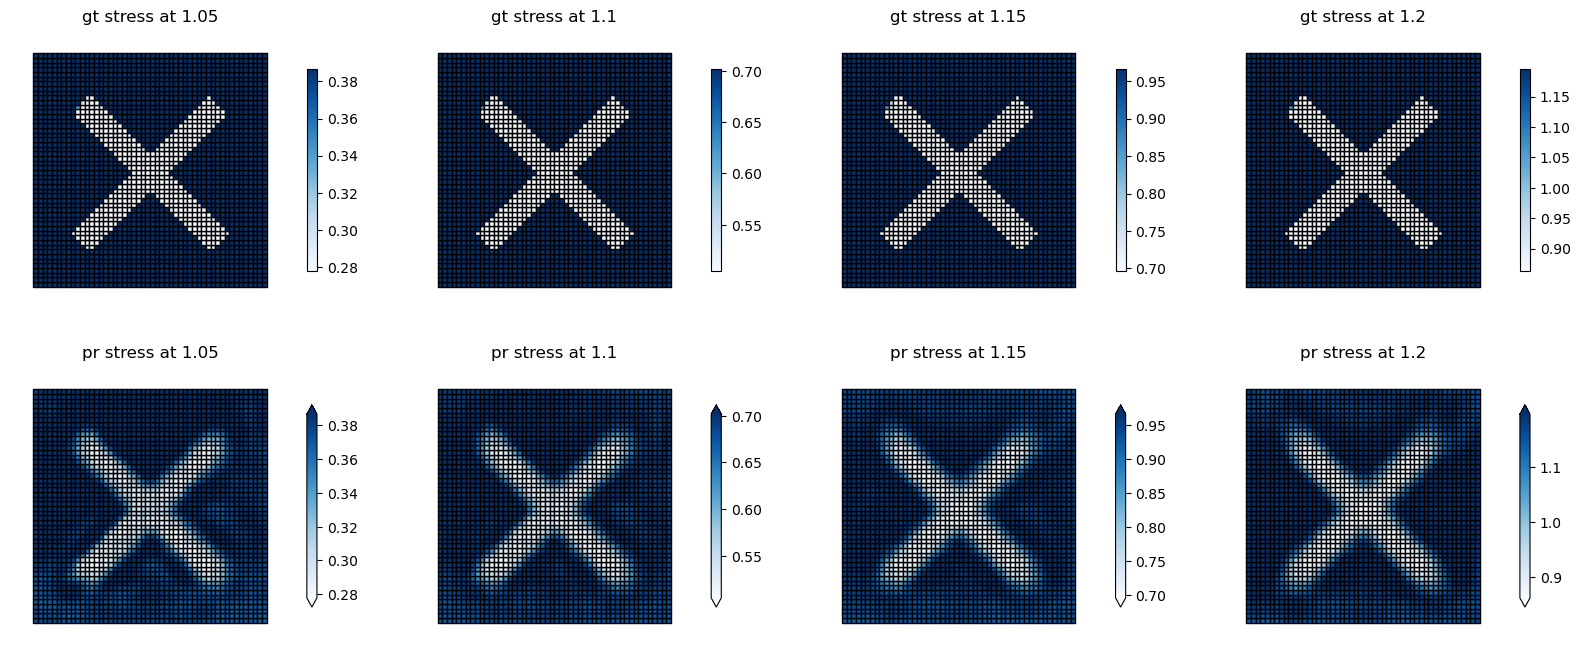

In [ ]:
# Stiffness across the domain
fig, axes = plt.subplots(2,4,figsize=(20,8))
for lmb, ax in zip(lmb_hist, axes.T):
    ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])

    params_gt = []
    for xy in elem_X:
        params_gt.append(coords_2_params_gt(xy))
    params_gt = np.array(params_gt)
    params_pr = ff_nn(elem_X, Lambda_params)

    c_elem_gt = []
    c_elem_pr = []
    for params_gt_i, params_pr_i in zip(params_gt, params_pr):
        c_elem_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, params_gt_i, 2)[0,0])
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[0,0])
    
    plotmesh(mesh.cells, mesh.points, c_elem_gt, title='gt stress at {}'.format(str(lmb)), ax=ax[0]); 
    extent = [np.min(c_elem_gt), np.max(c_elem_gt)]
    if extent[0] > np.min(c_elem_pr) and extent[1] < np.max(c_elem_pr):
        extend='both'
    elif extent[0] > np.min(c_elem_pr):
        extend='min'
    elif extent[1] < np.max(c_elem_pr):
        extend='max'
    plotmesh(mesh.cells, mesh.points, c_elem_pr, title='pr stress at {}'.format(str(lmb)), ax=ax[1], extent=extent, extend=extend); 

##### 10_by_10

In [ ]:
with open('×_paper_post_weak_form_50_by_50_hyper_1_10_by_10_200samples.npy', 'rb') as f:
    mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))

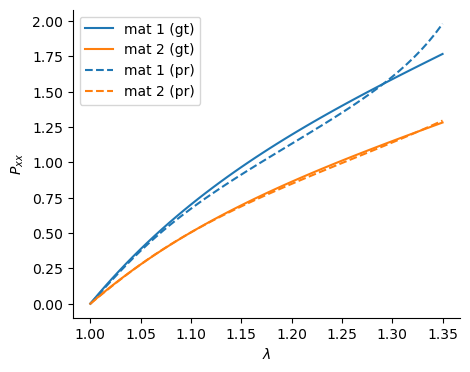

In [ ]:
mat1_params = coords_2_params_gt([0.0,0.0])
mat2_params = coords_2_params_gt([0.5,0.5])
mat1_P_gt = []
mat2_P_gt = []
mat1_P_pr = []
mat2_P_pr = []
# lmb_hist2 = [1.0, 1.005, 1.01, 1.02, 1.03, 1.04, 1.05, 1.10, 1.15, 1.20, 1.25, 1.30, 1.35]
lmb_hist2 = np.linspace(1,1.35)
for lmb in lmb_hist2:
    ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])
    mat1_P_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat1_params, 2)[0,0])
    mat2_P_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat2_params, 2)[0,0])

    mat1_params_pr = ff_nn(np.array([0.0, 0.0]), Lambda_params)
    mat2_params_pr = ff_nn(np.array([0.5, 0.5]), Lambda_params)
    mat1_P_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, mat1_params_pr, 2)[0,0])
    mat2_P_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, mat2_params_pr, 2)[0,0])

fig, ax = plt.subplots(figsize=(5,4))
ax.plot(lmb_hist2, mat1_P_gt, label='mat 1 (gt)')
ax.plot(lmb_hist2, mat2_P_gt, label='mat 2 (gt)')

fig.gca().set_prop_cycle(None)
ax.plot(lmb_hist2, mat1_P_pr, '--', label='mat 1 (pr)')
ax.plot(lmb_hist2, mat2_P_pr, '--', label='mat 2 (pr)')

ax.legend()
ax.set(xlabel='$\lambda$', ylabel='$P_{xx}$')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

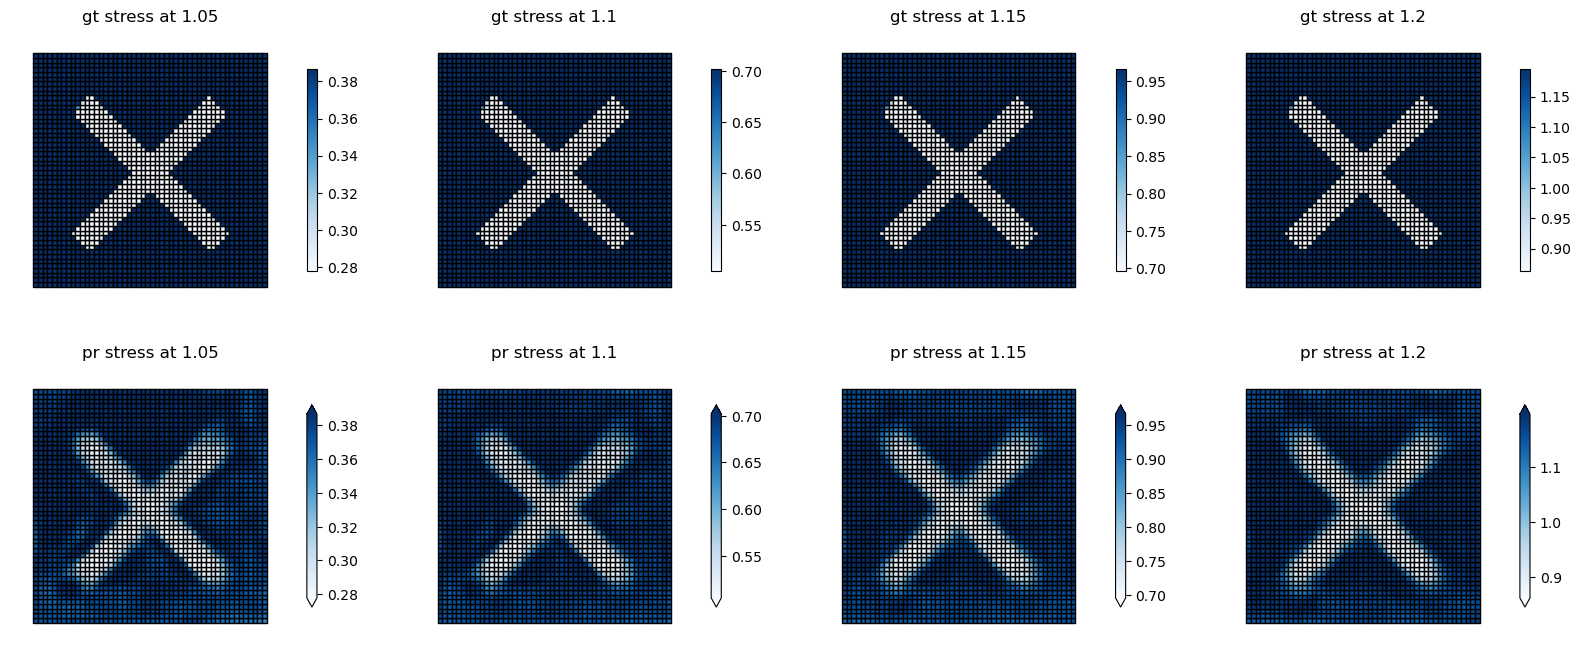

In [ ]:
# Stiffness across the domain
fig, axes = plt.subplots(2,4,figsize=(20,8))
for lmb, ax in zip(lmb_hist, axes.T):
    ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])

    params_gt = []
    for xy in elem_X:
        params_gt.append(coords_2_params_gt(xy))
    params_gt = np.array(params_gt)
    params_pr = ff_nn(elem_X, Lambda_params)

    c_elem_gt = []
    c_elem_pr = []
    for params_gt_i, params_pr_i in zip(params_gt, params_pr):
        c_elem_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, params_gt_i, 2)[0,0])
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[0,0])
    
    plotmesh(mesh.cells, mesh.points, c_elem_gt, title='gt stress at {}'.format(str(lmb)), ax=ax[0]); 
    extent = [np.min(c_elem_gt), np.max(c_elem_gt)]
    if extent[0] > np.min(c_elem_pr) and extent[1] < np.max(c_elem_pr):
        extend='both'
    elif extent[0] > np.min(c_elem_pr):
        extend='min'
    elif extent[1] < np.max(c_elem_pr):
        extend='max'
    plotmesh(mesh.cells, mesh.points, c_elem_pr, title='pr stress at {}'.format(str(lmb)), ax=ax[1], extent=extent, extend=extend); 

##### 5_by_5

In [ ]:
with open('×_paper_post_weak_form_50_by_50_hyper_1_5_by_5_100samples.npy', 'rb') as f:
    mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))

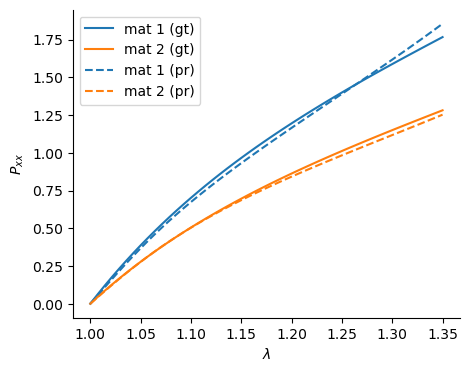

In [ ]:
mat1_params = coords_2_params_gt([0.0,0.0])
mat2_params = coords_2_params_gt([0.5,0.5])
mat1_P_gt = []
mat2_P_gt = []
mat1_P_pr = []
mat2_P_pr = []
# lmb_hist2 = [1.0, 1.005, 1.01, 1.02, 1.03, 1.04, 1.05, 1.10, 1.15, 1.20, 1.25, 1.30, 1.35]
lmb_hist2 = np.linspace(1,1.35)
for lmb in lmb_hist2:
    ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])
    mat1_P_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat1_params, 2)[0,0])
    mat2_P_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat2_params, 2)[0,0])

    mat1_params_pr = ff_nn(np.array([0.0, 0.0]), Lambda_params)
    mat2_params_pr = ff_nn(np.array([0.5, 0.5]), Lambda_params)
    mat1_P_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, mat1_params_pr, 2)[0,0])
    mat2_P_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, mat2_params_pr, 2)[0,0])

fig, ax = plt.subplots(figsize=(5,4))
ax.plot(lmb_hist2, mat1_P_gt, label='mat 1 (gt)')
ax.plot(lmb_hist2, mat2_P_gt, label='mat 2 (gt)')

fig.gca().set_prop_cycle(None)
ax.plot(lmb_hist2, mat1_P_pr, '--', label='mat 1 (pr)')
ax.plot(lmb_hist2, mat2_P_pr, '--', label='mat 2 (pr)')

ax.legend()
ax.set(xlabel='$\lambda$', ylabel='$P_{xx}$')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

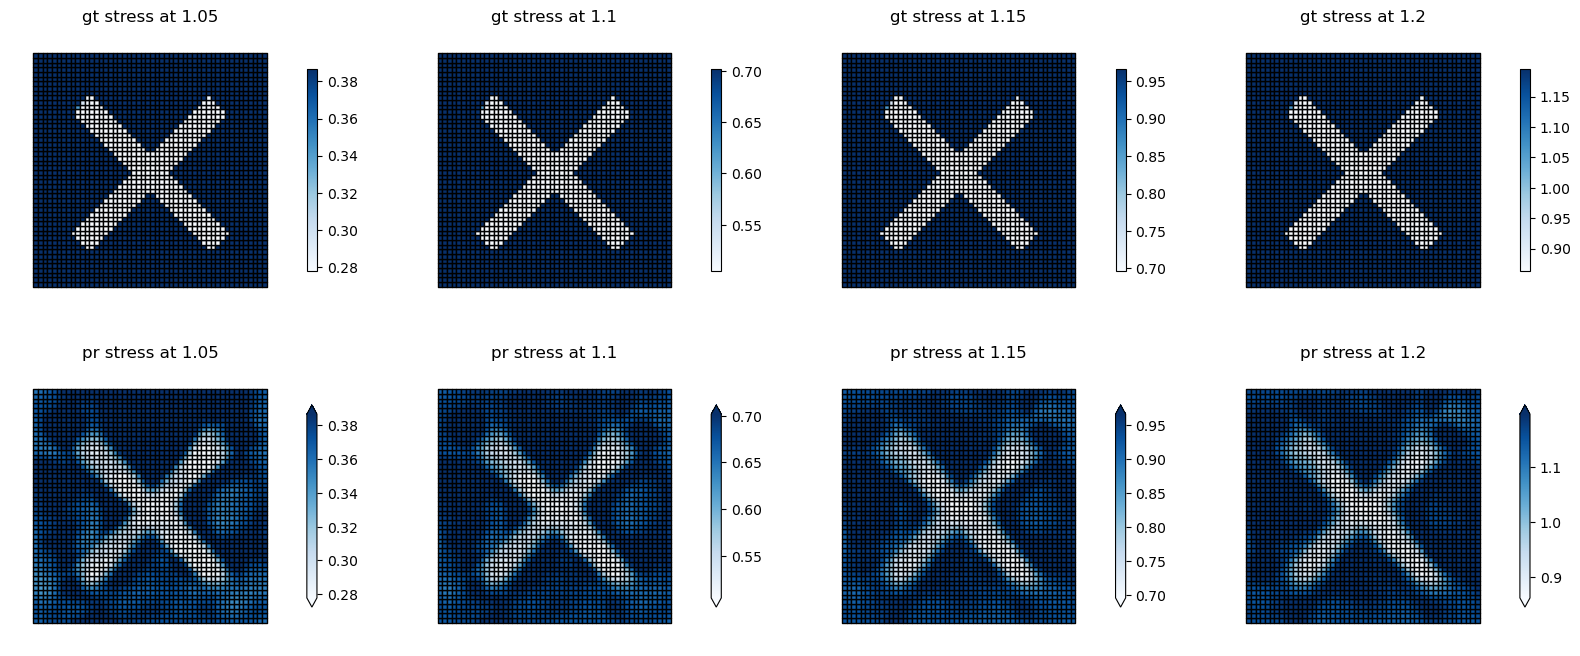

In [ ]:
# Stiffness across the domain
fig, axes = plt.subplots(2,4,figsize=(20,8))
for lmb, ax in zip(lmb_hist, axes.T):
    ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])

    params_gt = []
    for xy in elem_X:
        params_gt.append(coords_2_params_gt(xy))
    params_gt = np.array(params_gt)
    params_pr = ff_nn(elem_X, Lambda_params)

    c_elem_gt = []
    c_elem_pr = []
    for params_gt_i, params_pr_i in zip(params_gt, params_pr):
        c_elem_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, params_gt_i, 2)[0,0])
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[0,0])
    
    plotmesh(mesh.cells, mesh.points, c_elem_gt, title='gt stress at {}'.format(str(lmb)), ax=ax[0]); 
    extent = [np.min(c_elem_gt), np.max(c_elem_gt)]
    if extent[0] > np.min(c_elem_pr) and extent[1] < np.max(c_elem_pr):
        extend='both'
    elif extent[0] > np.min(c_elem_pr):
        extend='min'
    elif extent[1] < np.max(c_elem_pr):
        extend='max'
    plotmesh(mesh.cells, mesh.points, c_elem_pr, title='pr stress at {}'.format(str(lmb)), ax=ax[1], extent=extent, extend=extend); 

##### 2_by_2

In [ ]:
with open('×_paper_post_weak_form_50_by_50_hyper_1_2_by_2_36samples.npy', 'rb') as f:
    mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist = pickle.load(f)
# with open('×_paper_post_weak_form_50_by_50_hyper_1_2_by_2.npy', 'rb') as f:
#     mesh, elem_X, strains, Force_x, Force_y, node_params, Lambda_params, val_loss, metrics, t_hist, lmb_hist = pickle.load(f)
_, unravel = ravel_pytree(node_params)
NODE_w_unravel = lambda params: NODE_model_aniso(unravel(params))

In [ ]:
image = Image.open('×.png')
# image = image.filter(ImageFilter.GaussianBlur(radius=60))
image = image.rotate(-90)
image = np.array(image)
image = image.mean(axis=2)
image = image/image.max()

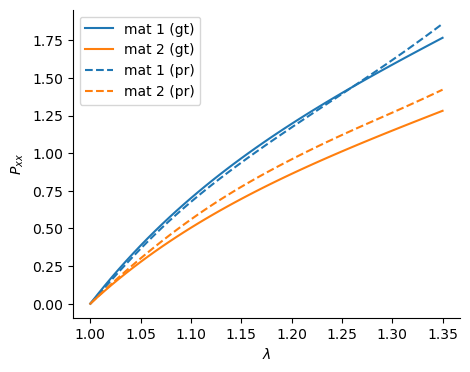

In [ ]:
mat1_params = coords_2_params_gt([0.0,0.0])
mat2_params = coords_2_params_gt([0.5,0.5])
mat1_P_gt = []
mat2_P_gt = []
mat1_P_pr = []
mat2_P_pr = []
# lmb_hist2 = [1.0, 1.005, 1.01, 1.02, 1.03, 1.04, 1.05, 1.10, 1.15, 1.20, 1.25, 1.30, 1.35]
lmb_hist2 = np.linspace(1,1.35)
for lmb in lmb_hist2:
    ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])
    mat1_P_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat1_params, 2)[0,0])
    mat2_P_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, mat2_params, 2)[0,0])

    mat1_params_pr = ff_nn(np.array([0.0, 0.0]), Lambda_params)
    mat2_params_pr = ff_nn(np.array([0.5, 0.5]), Lambda_params)
    mat1_P_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, mat1_params_pr, 2)[0,0])
    mat2_P_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, mat2_params_pr, 2)[0,0])

fig, ax = plt.subplots(figsize=(5,4))
ax.plot(lmb_hist2, mat1_P_gt, label='mat 1 (gt)')
ax.plot(lmb_hist2, mat2_P_gt, label='mat 2 (gt)')

fig.gca().set_prop_cycle(None)
ax.plot(lmb_hist2, mat1_P_pr, '--', label='mat 1 (pr)')
ax.plot(lmb_hist2, mat2_P_pr, '--', label='mat 2 (pr)')

ax.legend()
ax.set(xlabel='$\lambda$', ylabel='$P_{xx}$')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

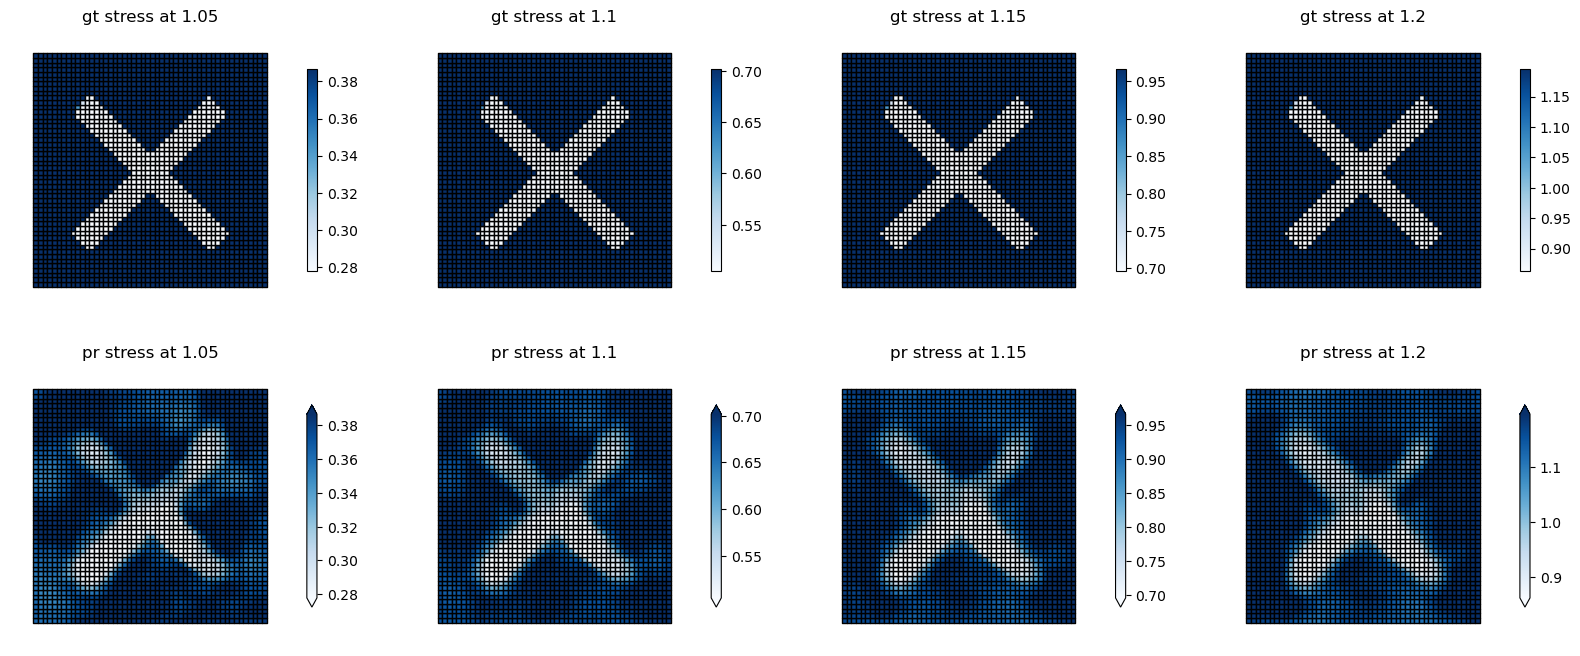

In [ ]:
# Stiffness across the domain
fig, axes = plt.subplots(2,4,figsize=(20,8))
for lmb, ax in zip(lmb_hist, axes.T):
    ugrad = jnp.array([[lmb-1.0, 0.0], [0.0, lmb-1.0]])

    params_gt = []
    for xy in elem_X:
        params_gt.append(coords_2_params_gt(xy))
    params_gt = np.array(params_gt)
    params_pr = ff_nn(elem_X, Lambda_params)

    c_elem_gt = []
    c_elem_pr = []
    for params_gt_i, params_pr_i in zip(params_gt, params_pr):
        c_elem_gt.append(ThreeDElasticity(GOH_model).ugrad_2_P(ugrad, params_gt_i, 2)[0,0])
        c_elem_pr.append(ThreeDElasticity(NODE_w_unravel).ugrad_2_P(ugrad, params_pr_i, 2)[0,0])
    
    plotmesh(mesh.cells, mesh.points, c_elem_gt, title='gt stress at {}'.format(str(lmb)), ax=ax[0]); 
    extent = [np.min(c_elem_gt), np.max(c_elem_gt)]
    if extent[0] > np.min(c_elem_pr) and extent[1] < np.max(c_elem_pr):
        extend='both'
    elif extent[0] > np.min(c_elem_pr):
        extend='min'
    elif extent[1] < np.max(c_elem_pr):
        extend='max'
    plotmesh(mesh.cells, mesh.points, c_elem_pr, title='pr stress at {}'.format(str(lmb)), ax=ax[1], extent=extent, extend=extend); 